In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch
import re
from twfv import run_em_like
from twfv.simulate import simulate_factor_data_bspline, missing_prob_from_factor_variance,sample_mask_from_varf
from twfv.cp import NaiveAbsoluteResidualCP, unflatten
from twfv import conditional_interval_report
from diagnosis import make_diagnosis_plots
import os
import matplotlib.colors as mcolors

import copy

def flatten(i: int, j: int, t: int, I: int, J: int, T: int) -> int:
    return i * (J * T) + j * T + t

In [2]:
def local_var_Y_from_info(info,print_i=0,print_t=30):
    """
    Compute per-subject/time/channel innovation variance:
      Var[epsilon_{i,t,j}] = kappa_i * sum_k X_{j,k}^2 * a2_{i,t,k} + s_i^2 * Psi_j

    Returns:
        var: array (I, T, J)
    """
    X = np.asarray(info["X_true"], dtype=float)          # (J, r)
    Psi = np.asarray(info["Psi_true"], dtype=float)      # (J,)
    s = np.asarray(info["s_true"], dtype=float)          # (I,)
    kappa = np.asarray(info["kappa_true"], dtype=float)  # (I,)
    a2 = np.asarray(info["a2_true"], dtype=float)        # (I, T, r) or (T, r)

    if a2.ndim == 2:  # allow (T, r) broadcast to subjects
        a2 = a2[None, ...]

    Xsq = X ** 2                     # (J, r)
    print(f'Xsq:{Xsq}')
    base = np.einsum("itr,jr->itj", a2, Xsq)  # sum_k X_{j,k}^2 * a2_{i,t,k}, shape (I, T, J)
    # print(f'np.cov(a2[0,:,0],a2[0,:,1]):{np.cov(a2[0,:,0],a2[0,:,1])}')
    print(f'a2[{print_i},:{print_t},0]:{a2[print_i,:print_t,0]}')
    print(f'base[{print_i},:{print_t},0]:{base[print_i,:print_t,0]}')
    print(f'kappa[{print_i}]:{kappa[print_i]}')
    print(f'base[{print_i},:{print_t},0]*kappa[{print_i}]:{base[print_i,:print_t,0]*kappa[print_i]}')
    print(f's[{print_i}]**2*Psi[0]:{s[print_i]**2*Psi[0]}')
    var = kappa[:, None, None] * base + (s ** 2)[:, None, None] * Psi[None, None, :]
    print(f'sd[{print_i},:{print_t},0]:{var[print_i,:print_t,0]**0.5}')
    return var  # (I, T, J)

In [3]:
I, T, J, r, M_ctrl = 30, 100, 5, 2, 20
alpha=0.1
seed=3
f_var=False
rng = np.random.default_rng(seed)
kappa_true = np.exp(rng.normal(1, 1, size=I))
kappa_true = np.sort(kappa_true)

# Make C_true autoregressive across M_ctrl (axis=-1)
C_true = np.zeros((I, r, M_ctrl))
ar_coef = 0.9  # AR(1) coefficient
for i in range(I):
    for k in range(r):
        noise = rng.normal(scale=2, size=M_ctrl)
        C_true[i, k, 0] = noise[0]
        for m in range(1, M_ctrl):
            C_true[i, k, m] = ar_coef * C_true[i, k, m-1] + (1-ar_coef**2)**0.5*noise[m]
val_proxy=np.zeros((I,T,r))
miss_prob_per_channel=np.linspace(0.3,0.6,J)
var_miss = True
if var_miss:
    Y, M, info = simulate_factor_data_bspline(
        I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1,f_var=f_var, use_variance_tied_missing=True,kappa_true=kappa_true,C_true=C_true
    )
    M, P = sample_mask_from_varf(I, T, info['X_true'], info['a2_true'], info['kappa_true'], seed=1, normalize="minmax_t",beta0=-1,beta1=1.5)
else:
    Y, M, info = simulate_factor_data_bspline( 
        I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1, use_variance_tied_missing=False,miss_prob_per_channel=miss_prob_per_channel,kappa_true=kappa_true,C_true=C_true,vol_proxy=val_proxy
    )
local_var_Y=local_var_Y_from_info(info)

Xsq:[[0.34231833 0.60003552]
 [0.32785311 1.10836175]
 [1.09588937 0.31120189]
 [0.55196603 0.40410339]
 [0.3608928  0.2208153 ]]
a2[0,:30,0]:[0.29280401 0.31282976 0.35892035 0.43546891 0.53816628 0.65205968
 0.78833259 0.91480992 1.04635303 1.14988733 1.24766988 1.32645979
 1.40109701 1.50237827 1.65453353 1.80554127 1.81891401 1.59595226
 1.12886758 0.72005492 0.46643435 0.36540792 0.36514456 0.41270689
 0.46673493 0.46375932 0.41010136 0.32606441 0.24487901 0.17898744]
base[0,:30,0]:[1.51425846 1.30684578 1.27543326 1.36041483 1.5634126  1.81499618
 2.08706324 2.36347512 2.63465641 2.87005571 2.99307837 3.01653883
 2.95500555 2.80830918 2.60381226 2.4024423  2.19876322 1.98137085
 1.7718572  1.59565022 1.36230473 1.04307912 0.7489885  0.55914724
 0.47654542 0.4572747  0.47357695 0.51843469 0.57627944 0.64656774]
kappa[0]:0.21104898177895165
base[0,:30,0]*kappa[0]:[0.31958271 0.27580847 0.26917889 0.28711417 0.32995664 0.3830531
 0.44047257 0.49880902 0.55604155 0.60572234 0.6316861

In [8]:
P_h = 0.6
M_h = P>np.median(P)
P[M_h]=P_h
P[~M_h]=0.5*P_h
U=rng.uniform(size=P.shape)
M = U>P

In [5]:
P = P*0
M = np.ones_like(P,dtype=bool)

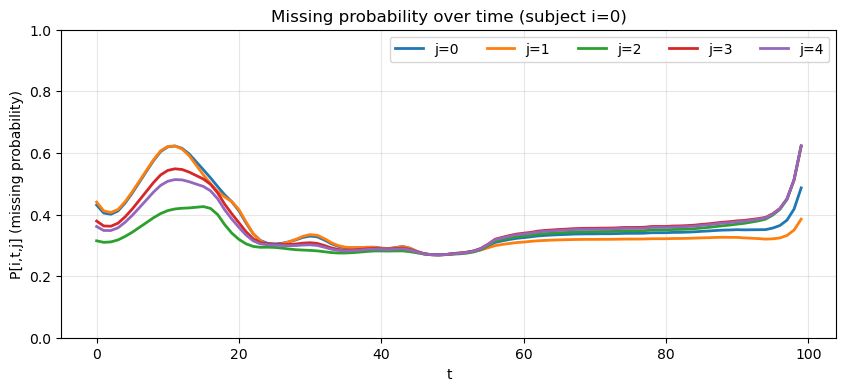

In [5]:
# pick a subject
i0 = 0  # change as needed

P_itj = np.asarray(P)  # (I,T,J)
I, T, J = P_itj.shape
t = np.arange(T)

plt.figure(figsize=(10, 4))
for j in range(J):
    plt.plot(t, P_itj[i0, :, j], label=f"j={j}", linewidth=2)

plt.ylim(0, 1)
plt.xlabel("t")
plt.ylabel("P[i,t,j] (missing probability)")
plt.title(f"Missing probability over time (subject i={i0})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=min(J, 5), loc="best")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(info['s_t_true'].shape[0]):  # Loop over subjects
    plt.plot(info['s_t_true'][i, :, 0], label=f"Subject {i}")
plt.xlabel("t (time)")
plt.ylabel("s_t_true[i, t, 0]")
plt.title("s_t_true for factor 0: each subject line over t")
plt.legend(title="Subject", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(C_true.shape[0]):  # Loop over subjects
    plt.plot(C_true[i, 0, :], label=f"Subject {i}")
plt.xlabel("M_ctrl (m)")
plt.ylabel("C_true[i, 0, m]")
plt.title("C_true for factor 0: each subject line over M_ctrl")
plt.legend(title="Subject", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
a2_true=info['a2_true']

T_range = np.arange(T)
plt.figure(figsize=(10, 5))
plt.plot(T_range, a2_true[9, :, 0], label='a2_true[1,:,0]', color='blue')
plt.xlabel('t (time)')
plt.ylabel('Value')
plt.title('a2_true[0,:,0] and phi_true[0,:] across T')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# Plot Y for subject 0, channels 0-4, showing observed and missing with different colors
subject_id = 20
plt.figure(figsize=(12, 16))
for j in range(J):
    plt.subplot(5, 1, j + 1)
    y_vals = Y[subject_id, :, j]  # shape (T,)
    m_mask = M[subject_id, :, j]  # shape (T,)
    t_vals = np.arange(Y.shape[1])

    # Plot observed points
    plt.plot(t_vals, y_vals, color='C0', label='full Y', alpha=0.8)
    plt.scatter(t_vals[m_mask], y_vals[m_mask], color='C0', label='Observed', alpha=0.8, s=18)
    # Plot missing points
    plt.scatter(t_vals[~m_mask], y_vals[~m_mask], color='C1', label='Missing', alpha=0.7, s=18, marker='x')
    
    var = local_var_Y[subject_id, :, j]  # shape (T,)
    plt.plot(t_vals, np.sqrt(var), 'k--', label='local sd (Y)')
    plt.plot(t_vals, -np.sqrt(var), 'k--', label='-local sd (Y)')
    plt.title(f"Y for subject {subject_id}, variable {j}")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()


In [ ]:
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_Y[0, :, j]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

In [ ]:
# Plot each variable (channel) of Y[0] across time
for j in range(Y.shape[2]):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(Y.shape[1]), Y[0, :, j])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f'Y[0] variable {j} across time')
    plt.show()

In [32]:
import torch

In [4]:
# --- 2) Build indices ---
uni_train = True
if uni_train:
    # --- 2) Build indices (uniform training sample) ---
    rng = np.random.default_rng(123)
    N = I * J * T
    all_idx = np.arange(N)

    # Uniformly sample training indices from ALL entries
    n_train = int(0.5 * N)
    train_idx = np.sort(rng.choice(all_idx, size=n_train, replace=False))

    # Flatten M into k-order: k = i*(J*T) + j*T + t
    M_flat = np.transpose(M, (0, 2, 1)).reshape(-1)  # (I,T,J) -> (I,J,T) -> flat

    # Among non-training entries: M=1 -> cal, M=0 -> test
    is_train = np.zeros(N, dtype=bool)
    is_train[train_idx] = True
    rest = ~is_train
    cal_idx = np.where(rest & M_flat)[0].astype(int)
    test_idx = np.where(rest & ~M_flat)[0].astype(int)
else:
    obs_idx_list = []
    test_idx_list = []
    for i in range(I):
        for t in range(T):
            for j in range(J):
                k = flatten(i, j, t, I, J, T)
                if M[i, t, j]:
                    obs_idx_list.append(k)
                else:
                    test_idx_list.append(k)
    obs_idx = np.array(obs_idx_list, dtype=int)
    test_idx = np.array(test_idx_list, dtype=int)

    # Shuffle observed indices and split into train/cal
    rng = np.random.default_rng(123)
    rng.shuffle(obs_idx)
    split = int(0.7 * obs_idx.size)
    train_idx = obs_idx[:split]
    cal_idx = obs_idx[split:]

# --- 3) Simple mean predictor (per-channel-individual mean over train observed) ---
individual_channel_sums = np.zeros((I, J), dtype=float)
individual_channel_counts = np.zeros((I, J), dtype=float)
for k in train_idx:
    i, j, t = unflatten(int(k), I, J, T)
    individual_channel_sums[i, j] += Y[i, t, j]
    individual_channel_counts[i, j] += 1.0
individual_channel_means = individual_channel_sums / np.clip(individual_channel_counts, 1.0, None)
res = Y - individual_channel_means[:,None, :]
# Check that the per-channel-individual mean of res on training idx are 0
means_check = np.zeros((I, J), dtype=float)
counts_check = np.zeros((I, J), dtype=float)
for k in train_idx:
    i, j, t = unflatten(int(k), I, J, T)
    means_check[i, j] += res[i, t, j]
    counts_check[i, j] += 1.0
per_channel_indiv_mean = means_check / np.clip(counts_check, 1.0, None)
print("Per-channel-individual mean of res on training idx (should be all ~0):")
# print(per_channel_indiv_mean)


from torch._C import device
degree: int = 3
max_outer: int = 50
grad_steps: int = 5
lr: float = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Y_torch = torch.as_tensor(Y, dtype=torch.float32, device=device)
def idx_to_mask_torch(idx, I, J, T, device=None):
    """
    Convert a 1D idx array and dimensions (I, J, T) to a boolean torch mask of shape (I, T, J).
    """
    flat_mask = np.zeros(I * J * T, dtype=bool)
    flat_mask[idx] = True
    # Reshape to (I, J, T) to match flatten convention, then transpose to (I, T, J)
    mask = flat_mask.reshape(I, J, T).transpose(0, 2, 1)
    return torch.as_tensor(mask, dtype=torch.bool, device=device)

M_train_torch = idx_to_mask_torch(train_idx, I, J, T, device=device)
M_cal_torch = idx_to_mask_torch(cal_idx, I, J, T, device=device)
M_test_torch = idx_to_mask_torch(test_idx, I, J, T, device=device)


Per-channel-individual mean of res on training idx (should be all ~0):


In [5]:
import pickle
seed_suffix = f"_seed{seed}"
r_fit=2
if not os.path.exists(f"em_result{seed_suffix}_r{r_fit}_{f_var}_vm{int(var_miss)}_uni{int(uni_train)}.pkl"):
    em_result = run_em_like(
        Y=Y_torch,
        M_mask=M_train_torch,
        r=r_fit,
        M_ctrl=int(M_ctrl),
        degree=degree,
        max_outer=max_outer,
        grad_steps=grad_steps,
        lr=lr,
        device=device,
        warp_eta=0.2,
        freeze_warp=True,
        use_woodbury=True,
        collect_diagnostics=True,
        diagnostics_t_head=10,
        lambda_C=0.01,
    )
    # M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)

    with open(f"em_result{seed_suffix}_r{r_fit}_{f_var}_vm{int(var_miss)}_uni{int(uni_train)}.pkl", "wb") as f:
        pickle.dump(em_result, f)
else:
    with open(f"em_result{seed_suffix}_r{r_fit}_{f_var}_vm{int(var_miss)}_uni{int(uni_train)}.pkl", "rb") as f:
        em_result = pickle.load(f)


In [115]:
info.keys()

dict_keys(['X_true', 'Psi_true', 's_true', 'kappa_true', 'C_true', 's_t_true', 'a2_true', 'log_a2_true', 'a2_true_means', 'u_tilde_true', 'vol_proxy', 'var_fs', 'knots', 'degree', 'miss_prob_per_channel', 'use_variance_tied_missing', 'seed'])

In [31]:
# import importlib
# import twfv
# importlib.reload(twfv)
from twfv import run_factor_channel_conformal
L, a2, psi, s, kappa, C, u_tilde, F_tilde, history = em_result
M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)
out_new = run_factor_channel_conformal(
    Y_torch, M_torch, L, psi, s, a2,
    alpha=0.1,
    factor_mode="leave_target_out",
    score_kind="pit",
)
lower_decomp, upper_decomp, center_decomp,cov_decomp = out_new["intervals"].values()
coverage_decomp  = (lower_decomp[~M_torch]<Y_torch[~M_torch]) & (Y_torch[~M_torch]<upper_decomp[~M_torch])
coverage_decomp.float().mean()


tensor(0.9052, device='cuda:0')

In [122]:
L = torch.as_tensor(info['X_true'], dtype=torch.float32, device=device)
psi = torch.as_tensor(info['Psi_true'], dtype=torch.float32, device=device)
s = torch.as_tensor(info['s_true'], dtype=torch.float32, device=device)
a2 = torch.as_tensor(info['a2_true'], dtype=torch.float32, device=device)
M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)
out_new = run_factor_channel_conformal(
    Y_torch, M_torch, L, psi, s, a2,
    alpha=0.1,
    factor_mode="leave_target_out",
    score_kind="standardized",
)
lower_decomp, upper_decomp, center_decomp,cov_decomp = out_new["intervals"].values()
coverage_decomp  = (lower_decomp[~M_torch]<Y_torch[~M_torch]) & (Y_torch[~M_torch]<upper_decomp[~M_torch])
coverage_decomp.float().mean()

tensor(0.9017, device='cuda:0')

In [119]:
L = torch.as_tensor(info['X_true'], dtype=torch.float32, device=device)
psi = torch.as_tensor(info['Psi_true'], dtype=torch.float32, device=device)
s = torch.as_tensor(info['s_true'], dtype=torch.float32, device=device)
a2 = torch.as_tensor(info['a2_true'], dtype=torch.float32, device=device)
M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)
out_new = run_factor_channel_conformal(
    Y_torch, M_torch, L, psi, s, a2,
    alpha=0.1,
    factor_mode="leave_target_out",
    score_kind="standardized",
)
lower_decomp, upper_decomp, center_decomp,cov_decomp = out_new["intervals"].values()
coverage_decomp  = (lower_decomp[~M_torch]<Y_torch[~M_torch]) & (Y_torch[~M_torch]<upper_decomp[~M_torch])
coverage_decomp.float().mean()

tensor(0.8945, device='cuda:0')

In [73]:
importlib.reload(twfv.decomp)

<module 'twfv.decomp' from 'j:\\research\\TWFVconformal\\twfv\\decomp.py'>

In [84]:
from twfv.decomp import run_factor_joint_conformal
out_joint = run_factor_joint_conformal(
    Y_torch,
    M_torch,
    L,
    psi,
    s,
    a2,
    alpha=0.2,
    factor_mode="observed",
    score_kind="mahalanobis",
    group_by="pattern",
)

joint_cov = out_joint["joint_coverage"]
proj = out_joint["projected_intervals"]
proj_cov = out_joint["projected_channel_coverage"]

print(joint_cov["coverage"])
print(proj["lower"].shape, proj["upper"].shape)
print(proj_cov["by_channel"][0]["coverage"])

0.8147722923842327
torch.Size([30, 100, 5]) torch.Size([30, 100, 5])
0.9340148698884758


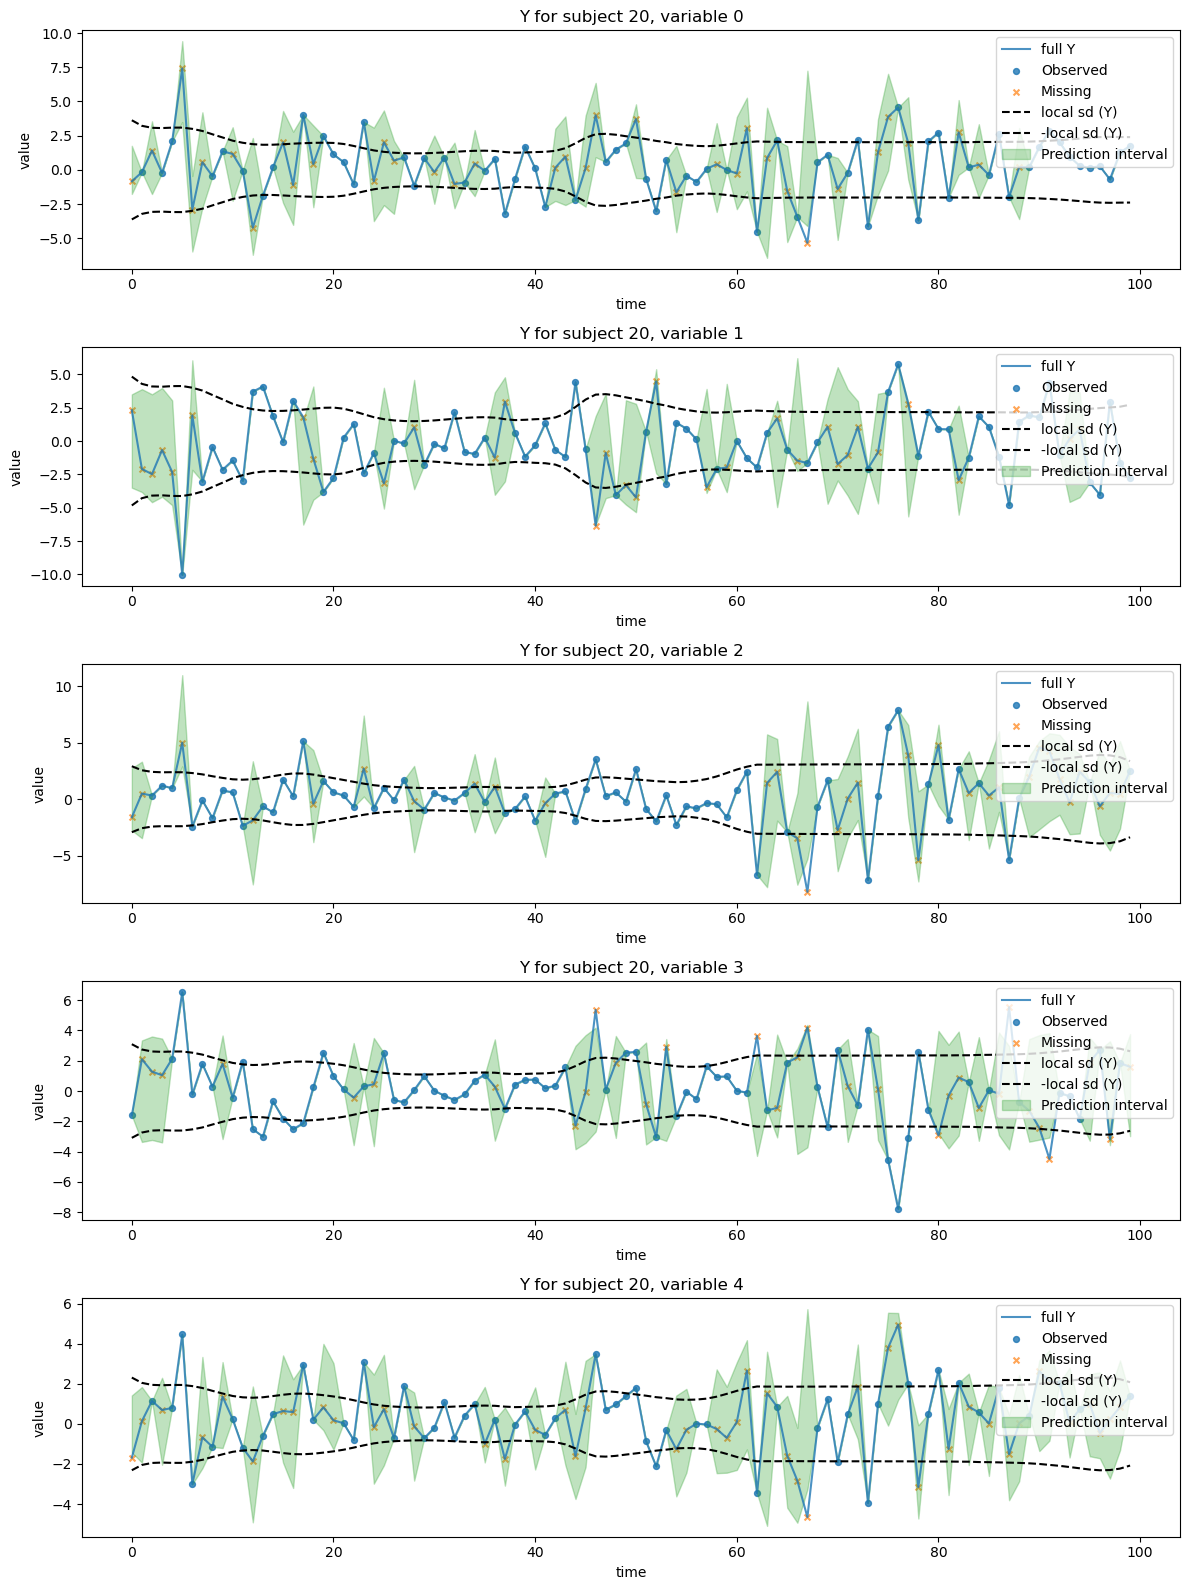

In [34]:
subject_id = 20
# Extract intervals and true Y for all times t at (i_plot, j_plot)
lower = lower_list[subject_id, :, :].cpu().detach().numpy()  # shape (T,)
upper = upper_list[subject_id, :, :].cpu().detach().numpy()  # shape (T,)
y_true = Y_torch[subject_id, :, :].cpu().detach().numpy()    # shape (T,)

plt.figure(figsize=(12, 16))
for j in range(J):
    plt.subplot(5, 1, j + 1)
    t_vals = np.arange(T)
    m_mask = M[subject_id, :, j]
    # Plot observed points
    plt.plot(t_vals, y_true[:,j], color='C0', label='full Y', alpha=0.8)
    plt.scatter(t_vals[m_mask], y_true[m_mask,j], color='C0', label='Observed', alpha=0.8, s=18)
    # Plot missing points
    plt.scatter(t_vals[~m_mask], y_true[~m_mask,j], color='C1', label='Missing', alpha=0.7, s=18, marker='x')
    
    var = local_var_Y[subject_id, :, j]  # shape (T,)
    plt.plot(t_vals, np.sqrt(var), 'k--', label='local sd (Y)')
    plt.plot(t_vals, -np.sqrt(var), 'k--', label='-local sd (Y)')
    plt.fill_between(t_vals, lower[:,j], upper[:,j], color='C2', alpha=0.3, label='Prediction interval')
    plt.title(f"Y for subject {subject_id}, variable {j}")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

In [10]:
from twfv import split_cal_test_from_train_and_pmiss
P = np.broadcast_to(miss_prob_per_channel, (I, T, J))
cal_idx, test_idx = split_cal_test_from_train_and_pmiss(train_idx, P, seed=123)

In [7]:
em_result[-1].keys()

dict_keys(['ll_outer', 'll_post_m', 't_outer_total_s', 't_estep_s', 't_warp_s', 't_mstep_s', 't_post_s', 't_total_s', 'C0_mean', 'C0_std', 'C0_max_abs', 'u_head_mean', 'u_head_inc_mean', 'u_head_inc_min', 'a2_head_mean', 'a2_head_max', 'dL_rel', 'dC_rel', 'dlogpsi_l2', 'dlogs_l2', 'du_rel', 'da2_rel', 'dvar_y_rmse', 'dvar_y_rel_l2', 'dvar_y_max_rel', 'dH_frob_mean', 'dH_rel_frob_mean', 'dH_rel_frob_max'])

In [6]:
def conditional_coverage(test_idx, covered, I, J, T, *,
                         subjects=None, channels=None, t_range=None):
    """
    subjects: iterable of subject ids (i) to include, or None for all
    channels: iterable of channel ids (j) to include, or None for all
    t_range: (t_min, t_max) inclusive, or None for all
    """
    subjects = None if subjects is None else set(subjects)
    channels = None if channels is None else set(channels)

    keep = np.ones(test_idx.size, dtype=bool)

    for n, k in enumerate(test_idx.tolist()):
        i, j, t = unflatten(int(k), I, J, T)

        if subjects is not None and i not in subjects:
            keep[n] = False
            continue
        if channels is not None and j not in channels:
            keep[n] = False
            continue
        if t_range is not None:
            t0, t1 = t_range
            if not (t0 <= t <= t1):
                keep[n] = False
                continue

    if not np.any(keep):
        return float("nan"), 0  # no points in that subset

    return float(np.mean(covered[keep])), int(np.sum(keep))

In [7]:
# # Calibration true and fitted
# def filter_idx_by_time(idx, I, J, T, t_lo=10, t_hi=90):
#     keep = np.zeros(idx.size, dtype=bool)
#     for n, k in enumerate(idx.tolist()):
#         _, _, t = unflatten(int(k), I, J, T)
#         keep[n] = (t_lo <= t <= t_hi)
#     return idx[keep]
# cal_idx = filter_idx_by_time(cal_idx, I, J, T, t_lo=10, t_hi=90)
# test_idx = filter_idx_by_time(test_idx, I, J, T, t_lo=10, t_hi=90)

Y_cal_true = np.zeros(cal_idx.size, dtype=float)
for n, k in enumerate(cal_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    Y_cal_true[n] = Y[i, t, j]
Y_test_true = np.zeros(test_idx.size, dtype=float)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    Y_test_true[n] = Y[i, t, j]

Y_cal_fit = np.zeros(cal_idx.size, dtype=float)
Y_test_fit = np.zeros(test_idx.size, dtype=float)

In [8]:
def conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal, Y_test_fit, sigma_test, alpha=0.1, sigma_min=1e-6):
    sigma_cal = np.maximum(sigma_cal, sigma_min)
    sigma_test = np.maximum(sigma_test, sigma_min)

    S_cal = np.abs(Y_cal_true - Y_cal_fit) / sigma_cal

    m = S_cal.size
    q_level = min(1.0, np.ceil((m + 1) * (1 - alpha)) / m)
    try:
        q = np.quantile(S_cal, q_level, method="higher")
    except TypeError:
        q = np.quantile(S_cal, q_level, interpolation="higher")

    lower = Y_test_fit - q * sigma_test
    upper = Y_test_fit + q * sigma_test
    lower_cal = Y_cal_fit - q * sigma_cal
    upper_cal = Y_cal_fit + q * sigma_cal
    return lower, upper, q, lower_cal, upper_cal

In [142]:
subj_cal = np.zeros(cal_idx.size, dtype=int)
for n, k in enumerate(cal_idx.tolist()):
    i, _, _ = unflatten(int(k), I, J, T)
    subj_cal[n] = i

subj_test = np.zeros(test_idx.size, dtype=int)
for n, k in enumerate(test_idx.tolist()):
    i, _, _ = unflatten(int(k), I, J, T)
    subj_test[n] = i

def conformal_scaled_abs_per_subject(
    Y_cal_true,
    Y_cal_fit,
    sigma_cal,
    subj_cal,
    Y_test_fit,
    sigma_test,
    subj_test,
    exact_coverage=False,
    alpha=0.1,
    sigma_min=1e-6,
    min_cal_per_subject=20,
):
    """
    Per-subject calibrated scaled-absolute CP.
    Returns test intervals and calibration intervals; each cal point uses its subject's q_i.
    """
    Y_cal_true = np.asarray(Y_cal_true, dtype=float).ravel()
    Y_cal_fit = np.asarray(Y_cal_fit, dtype=float).ravel()
    sigma_cal = np.asarray(sigma_cal, dtype=float).ravel()
    subj_cal = np.asarray(subj_cal, dtype=int).ravel()

    Y_test_fit = np.asarray(Y_test_fit, dtype=float).ravel()
    sigma_test = np.asarray(sigma_test, dtype=float).ravel()
    subj_test = np.asarray(subj_test, dtype=int).ravel()

    if not (Y_cal_true.size == Y_cal_fit.size == sigma_cal.size == subj_cal.size):
        raise ValueError("cal arrays must have same length")
    if not (Y_test_fit.size == sigma_test.size == subj_test.size):
        raise ValueError("test arrays must have same length")

    sigma_cal = np.maximum(sigma_cal, sigma_min)
    sigma_test = np.maximum(sigma_test, sigma_min)

    # global fallback
    S_cal_all = np.abs(Y_cal_true - Y_cal_fit) / sigma_cal
    m_all = S_cal_all.size
    q_level_all = min(1.0, np.ceil((m_all + 1) * (1 - alpha)) / m_all)
    if exact_coverage:
        q_level_all = 1-alpha
    try:
        q_global = np.quantile(S_cal_all, q_level_all, method="higher")
    except TypeError:
        q_global = np.quantile(S_cal_all, q_level_all, interpolation="higher")

    # compute q_i per subject
    q_by_subject = {}
    for i in np.unique(np.concatenate([subj_cal, subj_test])):
        m_cal = (subj_cal == i)
        if np.sum(m_cal) >= int(min_cal_per_subject):
            S_i = np.abs(Y_cal_true[m_cal] - Y_cal_fit[m_cal]) / sigma_cal[m_cal]
            m_i = S_i.size
            q_level = min(1.0, np.ceil((m_i + 1) * (1 - alpha)) / m_i)
            if exact_coverage:
                q_level = 1-alpha
            try:
                q_i = np.quantile(S_i, q_level, method="higher")
                print('q_i covered',(S_i<=q_i).mean())
            except TypeError:
                q_i = np.quantile(S_i, q_level, interpolation="higher")
                print('q_i covered',(S_i<=q_i).mean())
        else:
            q_i = float(q_global)
        q_by_subject[int(i)] = float(q_i)

    # test intervals
    lower = np.empty_like(Y_test_fit, dtype=float)
    upper = np.empty_like(Y_test_fit, dtype=float)
    for i in np.unique(subj_test):
        m_test = (subj_test == i)
        q_i = q_by_subject.get(int(i), q_global)
        lower[m_test] = Y_test_fit[m_test] - q_i * sigma_test[m_test]
        upper[m_test] = Y_test_fit[m_test] + q_i * sigma_test[m_test]

    # cal intervals using each point's subject q_i
    lower_cal = np.empty_like(Y_cal_fit, dtype=float)
    upper_cal = np.empty_like(Y_cal_fit, dtype=float)
    for k in range(subj_cal.size):
        i = int(subj_cal[k])
        q_i = q_by_subject.get(i, q_global)
        lower_cal[k] = Y_cal_fit[k] - q_i * sigma_cal[k]
        upper_cal[k] = Y_cal_fit[k] + q_i * sigma_cal[k]

    return lower, upper, lower_cal, upper_cal, q_by_subject, q_global


In [9]:
def local_var_from_fit(L, a2, psi, s, kappa):
    with torch.no_grad():
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))                  # (I,T,J)
        var = kappa[:, None, None] * base + (s**2)[:, None, None] * psi[None, None, :]
    return var
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4]).cpu().numpy()

In [10]:
import scipy

sigma_fitted = np.sqrt(local_var_fitted)
sigma_flat = np.transpose(sigma_fitted, (0, 2, 1)).reshape(-1)  # (I*J*T,)
sigma_oracle_flat=np.transpose(np.sqrt(local_var_Y), (0, 2, 1)).reshape(-1)  # (I*J*T,)

sigma_cal  = sigma_flat[cal_idx]
sigma_test = sigma_flat[test_idx]
sigma_cal_oracle=sigma_oracle_flat[cal_idx]
sigma_test_oracle=sigma_oracle_flat[test_idx]
sigma_cal_avg = (sigma_cal_oracle+sigma_cal)/2
sigma_test_avg = (sigma_test_oracle+sigma_test)/2
q95 = scipy.stats.norm.ppf(0.95)  # for 90% two-sided
lower_cal_oracle = -q95 * sigma_cal_oracle+Y_cal_fit
upper_cal_oracle =  q95 * sigma_cal_oracle+Y_cal_fit
lower_oracle = -q95 * sigma_test_oracle+Y_test_fit
upper_oracle =  q95 * sigma_test_oracle+Y_test_fit
lower_cal_avg = -q95 * sigma_cal_avg+Y_cal_fit
upper_cal_avg =  q95 * sigma_cal_avg+Y_cal_fit
lower_avg = -q95 * sigma_test_avg+Y_test_fit
upper_avg =  q95 * sigma_test_avg+Y_test_fit
# oracle_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal_oracle, Y_test_fit, sigma_test_oracle, alpha=0.1, sigma_min=1e-6)
# avg_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal_avg, Y_test_fit, sigma_test_avg, alpha=0.1, sigma_min=1e-6)

t_test = np.zeros(test_idx.size, dtype=int)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    t_test[n] = t
# lower_oracle,upper_oracle,q_oracle,lower_cal_oracle,upper_cal_oracle=oracle_result
covered_oracle = (Y_test_true >= lower_oracle) & (Y_test_true <= upper_oracle)
report_oracle = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_oracle,
    upper=upper_oracle,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)
# lower_avg,upper_avg,q_avg,lower_cal_avg,upper_cal_avg=avg_result
covered_avg = (Y_test_true >= lower_avg) & (Y_test_true <= upper_avg)
report_avg = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_avg,
    upper=upper_avg,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

In [ ]:
tmfv_result=conformal_scaled_abs_per_subject(Y_cal_true, Y_cal_fit, sigma_cal, subj_cal, Y_test_fit, sigma_test, subj_test, alpha=0.1, sigma_min=1e-6)
oracle_result=conformal_scaled_abs_per_subject(Y_cal_true, Y_cal_fit, sigma_cal_oracle, subj_cal, Y_test_fit, sigma_test_oracle, subj_test,exact_coverage=True, alpha=0.1, sigma_min=1e-6)
lower_tmfv, upper_tmfv, lower_tmfv_cal, upper_tmfv_cal, q_tmfv_by_subject, q_tmfv_global = tmfv_result
covered_tmfv = (Y_test_true >= lower_tmfv) & (Y_test_true <= upper_tmfv)
cov_twfv = float(np.mean(covered_tmfv)) if covered_tmfv.size > 0 else float("nan")
covered_tmfv_cal = (Y_cal_true >= lower_tmfv_cal) & (Y_cal_true <= upper_tmfv_cal)
cov_twfv_cal = float(np.mean(covered_tmfv_cal)) if covered_tmfv_cal.size > 0 else float("nan")
lower_oracle, upper_oracle, lower_cal_oracle, upper_cal_oracle, q_oracle_by_subject, q_oracle_global = oracle_result
covered_oracle = (Y_test_true >= lower_oracle) & (Y_test_true <= upper_oracle)
cov_oracle = float(np.mean(covered_oracle)) if covered_oracle.size > 0 else float("nan")
covered_oracle_cal = (Y_cal_true >= lower_cal_oracle) & (Y_cal_true <= upper_cal_oracle)
cov_oracle_cal = float(np.mean(covered_oracle_cal)) if covered_oracle_cal.size > 0 else float("nan")

In [127]:
oracle_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal_oracle, Y_test_fit, sigma_test_oracle, alpha=0.1, sigma_min=1e-6)
lower_oracle, upper_oracle, q_oracle, lower_cal_oracle, upper_cal_oracle = oracle_result
covered_oracle = (Y_test_true >= lower_oracle) & (Y_test_true <= upper_oracle)
cov_oracle = float(np.mean(covered_oracle)) if covered_oracle.size > 0 else float("nan")
S_cal_oracle=np.abs(Y_cal_true-Y_cal_fit)/sigma_cal_oracle
S_test_oracle=np.abs(Y_test_true-Y_test_fit)/sigma_test_oracle
q_cal_oracle=np.quantile(S_cal_oracle, 1-alpha)
q_test_oracle=np.quantile(S_test_oracle, 1-alpha)
covered_oracle_cal = (Y_cal_true >= lower_cal_oracle) & (Y_cal_true <= upper_cal_oracle)
cov_oracle_cal = float(np.mean(covered_oracle_cal)) if covered_oracle_cal.size > 0 else float("nan")
print(f'q_cal_oracle:{q_cal_oracle},q_test_oracle:{q_test_oracle}')
print(f'cov_oracle:{cov_oracle},cov_oracle_cal:{cov_oracle_cal}')

q_cal_oracle:1.639536403541707,q_test_oracle:1.599705124275937
cov_oracle:0.9093841642228739,cov_oracle_cal:0.9009779951100244


In [19]:
from twfv.cp import LocalizedSplitConformalCP
from twfv.metrics import conditional_interval_report

# --- assumes you already have ---
# Y: (I, T, J) true data (with missing values possibly filled; we index via M anyway)
# M: (I, T, J) bool mask, True = observed, False = missing/test
# Y_hat: (I, T, J) fitted mean predictions for all (i,t,j)
# obs_idx, test_idx from your cell (must match flatten below)

alpha = 0.1
n_bins = 10

# IMPORTANT: make sure your flatten matches twfv.cp.unflatten convention:
# k = i*(J*T) + j*T + t
def flatten(i: int, j: int, t: int, I: int, J: int, T: int) -> int:
    return i * (J * T) + j * T + t

# Flatten Y / Y_hat in (i, j, t) order to match the indices above
Y_flat = np.transpose(np.asarray(Y), (0, 2, 1)).reshape(-1)        # (I*J*T,)
Yhat_flat = np.zeros(Y.size,dtype=float)

# --- Localized Split Conformal (calibrate on observed points) ---
lcp = LocalizedSplitConformalCP(shape_ref=np.asarray(Y), J=J, alpha=alpha)
obs_idx = np.unique(np.concat((cal_idx,train_idx)))
lcp.calibrate_from_fit(
    X_cal_idx=obs_idx,
    Y_cal_true=Y_flat[obs_idx],
    Y_cal_fit=Yhat_flat[obs_idx],
)

intervals = lcp.predict_interval_from_fit(
    X_test_idx=test_idx,
    Y_test_fit=Yhat_flat[test_idx],
    alpha=alpha,
)
lower_lcp = intervals[:, 0]
upper_lcp = intervals[:, 1]

y_test_true = Y_flat[test_idx]
covered_lcp = (y_test_true >= lower_lcp) & (y_test_true <= upper_lcp)
print("LCP coverage:", float(np.mean(covered_lcp)))
print("LCP avg length:", float(np.mean(upper_lcp - lower_lcp)))

# Use time as X for conditional report (vectorized from the flattening convention)
t_test = (np.asarray(test_idx) % T).astype(float)

report_lcp = conditional_interval_report(
    y_true=y_test_true,
    lower=lower_lcp,
    upper=upper_lcp,
    x=t_test,                  # partitions by time
    y_hat=Yhat_flat[test_idx], # enables abs_resid partition
    n_bins=n_bins,
)

report_lcp  # dict with keys like "X", "Y", "abs_resid"

LCP coverage: 0.8673544583640383
LCP avg length: 6.882593702446137


{'Y': {'name': 'Y',
  'edges': array([-24.34346621,  -2.62187912,  -1.48264547,  -0.85532756,
          -0.403349  ,   0.02643318,   0.43211726,   0.85605229,
           1.44824506,   2.66130289,  22.89054427]),
  'rows': [{'bin': 0,
    'left': -24.34346620671228,
    'right': -2.621879121142597,
    'n': 272,
    'coverage': 0.3639705882352941,
    'avg_length': 6.905549048818298,
    'avg_value': -5.055346523560233,
    'avg_y': -5.055346523560233},
   {'bin': 1,
    'left': -2.621879121142597,
    'right': -1.482645467649282,
    'n': 271,
    'coverage': 1.0,
    'avg_length': 6.878677977183101,
    'avg_value': -1.9559484931474422,
    'avg_y': -1.9559484931474422},
   {'bin': 2,
    'left': -1.482645467649282,
    'right': -0.8553275557855035,
    'n': 271,
    'coverage': 1.0,
    'avg_length': 6.887811444976759,
    'avg_value': -1.1299436044911284,
    'avg_y': -1.1299436044911284},
   {'bin': 3,
    'left': -0.8553275557855035,
    'right': -0.40334899996686185,
    'n': 272

In [20]:
from twfv.cp import CPTDRSplitConformalCP

cp = CPTDRSplitConformalCP(shape_ref=Y, J=J, alpha=alpha, series_mode="ij", lambda_prior=1.0)

cp.calibrate_from_fit(X_cal_idx=cal_idx, Y_cal_true=Y_cal_true, Y_cal_fit=Y_cal_fit)

intervals = cp.predict_interval_from_fit(X_test_idx=test_idx, Y_test_fit=Y_test_fit, alpha=alpha)
lower_cptdr = intervals[:, 0]
upper_cptdr = intervals[:, 1]

# Partition variable: time t extracted from flatten convention k=i*(J*T)+j*T+t
t_test = (test_idx % T).astype(int)

report_cptdr = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_cptdr,
    upper=upper_cptdr,
    x=t_test,          # gives you report["X"] by time bins
    y_hat=Y_test_fit,  # gives you report["abs_resid"] bins too
    n_bins=10,
)
y_test_true = Y_flat[test_idx]
covered_cptdr = (y_test_true >= lower_cptdr) & (y_test_true <= upper_cptdr)
print("CPTDR coverage:", float(np.mean(covered_cptdr)))
print("CPTDR avg length:", float(np.mean(upper_cptdr - lower_cptdr)))

CPTDR coverage: 0.9005158437730287
CPTDR avg length: 8.04428304401286


In [21]:
tmfv_result=conformal_scaled_abs(Y_cal_true, Y_cal_fit, sigma_cal, Y_test_fit, sigma_test, alpha=0.1, sigma_min=1e-6)
lower_tmfv, upper_tmfv, q_tmfv, lower_tmfv_cal, upper_tmfv_cal = tmfv_result
covered_tmfv = (Y_test_true >= lower_tmfv) & (Y_test_true <= upper_tmfv)
cov_twfv = float(np.mean(covered_tmfv)) if covered_tmfv.size > 0 else float("nan")
covered_tmfv_cal = (Y_cal_true >= lower_tmfv_cal) & (Y_cal_true <= upper_tmfv_cal)
cov_twfv_cal = float(np.mean(covered_tmfv_cal)) if covered_tmfv_cal.size > 0 else float("nan")
# arrays over test points (1D, same length)
# y_test_true, lower, upper are required
# x_test can be time or any covariate aligned with the test points
# y_test_fit optional (to compute |residual| partitions)
report_tmfv = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_tmfv,
    upper=upper_tmfv,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

# --- 4) Conformal calibration and prediction ---
cp = NaiveAbsoluteResidualCP(shape_ref=Y, J=J, alpha=0.1)
cp.calibrate_from_fit(cal_idx, Y_cal_true, Y_cal_fit)
intervals = cp.predict_interval_from_fit(test_idx, Y_test_fit, alpha=0.1)

# --- 5) Evaluate coverage on masked entries ---
lower = intervals[:, 0]
upper = intervals[:, 1]
covered_scp = (Y_test_true >= lower) & (Y_test_true <= upper)
report_scp = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower,
    upper=upper,
    x=t_test,          # e.g., time index t_test
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

In [39]:
cov_oracle = np.mean(covered_oracle)
covered_oracle_cal = (Y_cal_true >= lower_cal_oracle) & (Y_cal_true <= upper_cal_oracle)
cov_oracle_cal = float(np.mean(covered_oracle_cal)) if covered_oracle_cal.size > 0 else float("nan")
cov_avg = np.mean(covered_avg)
covered_avg_cal = (Y_cal_true >= lower_cal_avg) & (Y_cal_true <= upper_cal_avg)
cov_avg_cal = float(np.mean(covered_avg_cal)) if covered_avg_cal.size > 0 else float("nan")
print(f'cov_oracle:{cov_oracle},cov_avg:{cov_avg},cov_twfv:{cov_twfv}')
print(f'cov_oracle_cal:{cov_oracle_cal},cov_avg_cal:{cov_avg_cal},cov_twfv_cal:{cov_twfv_cal}')

cov_oracle:0.9028316524437549,cov_avg:0.9181536074476339,cov_twfv:0.8886733902249806
cov_oracle_cal:0.8777928232904536,cov_avg_cal:0.9035206499661476,cov_twfv_cal:0.9004739336492891


In [64]:
import importlib
import twfv
importlib.reload(twfv.diagnostics)

<module 'twfv.diagnostics' from 'j:\\research\\TWFVconformal\\twfv\\diagnostics.py'>

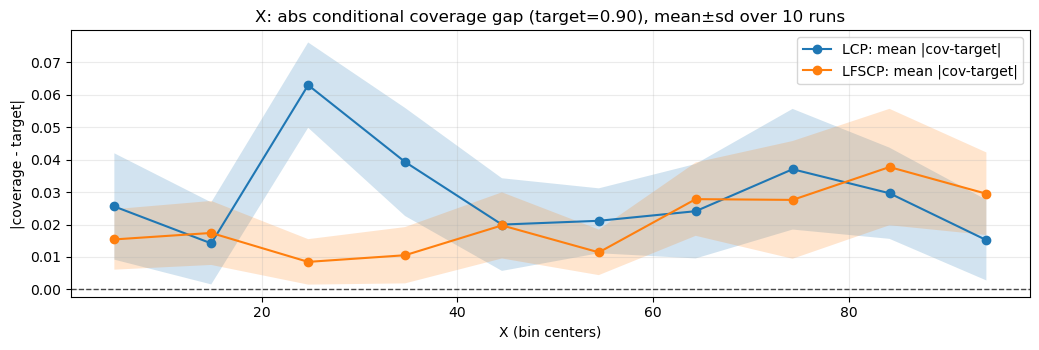

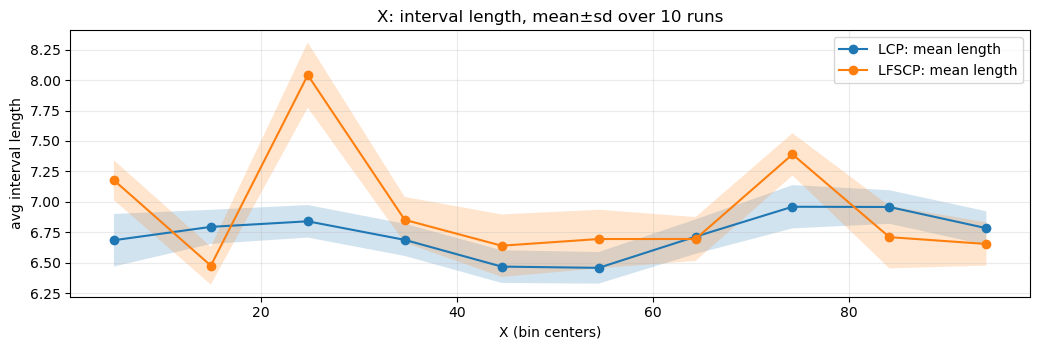

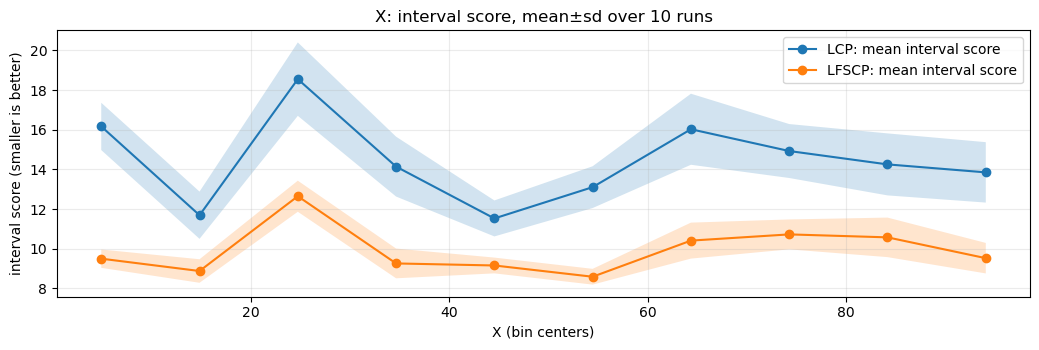

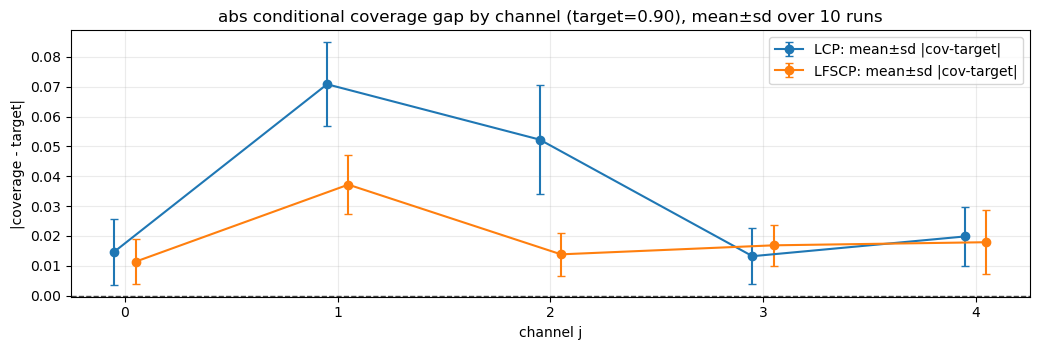

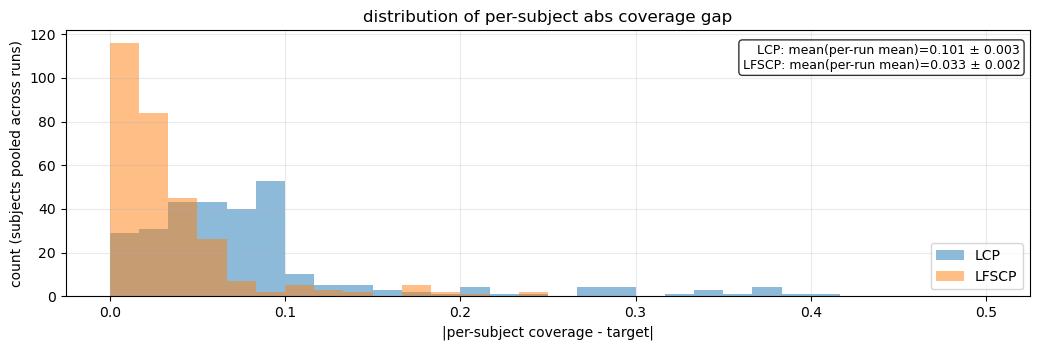

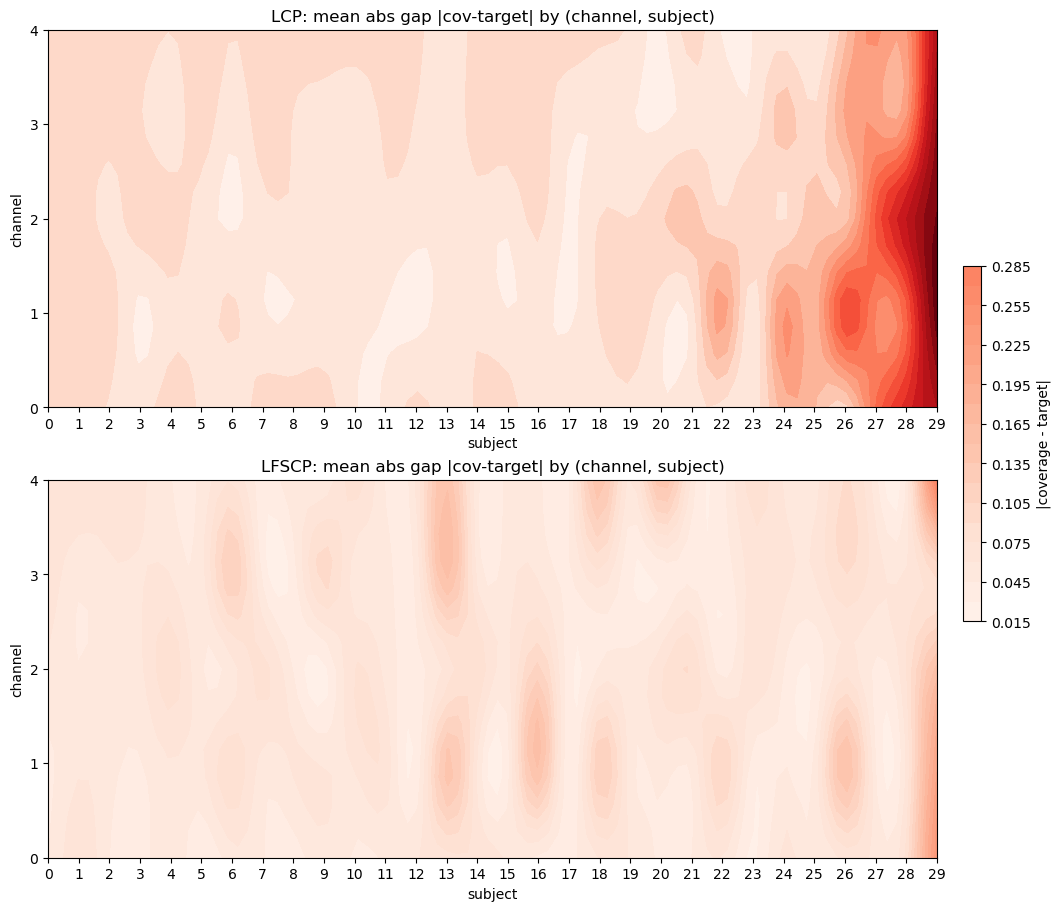

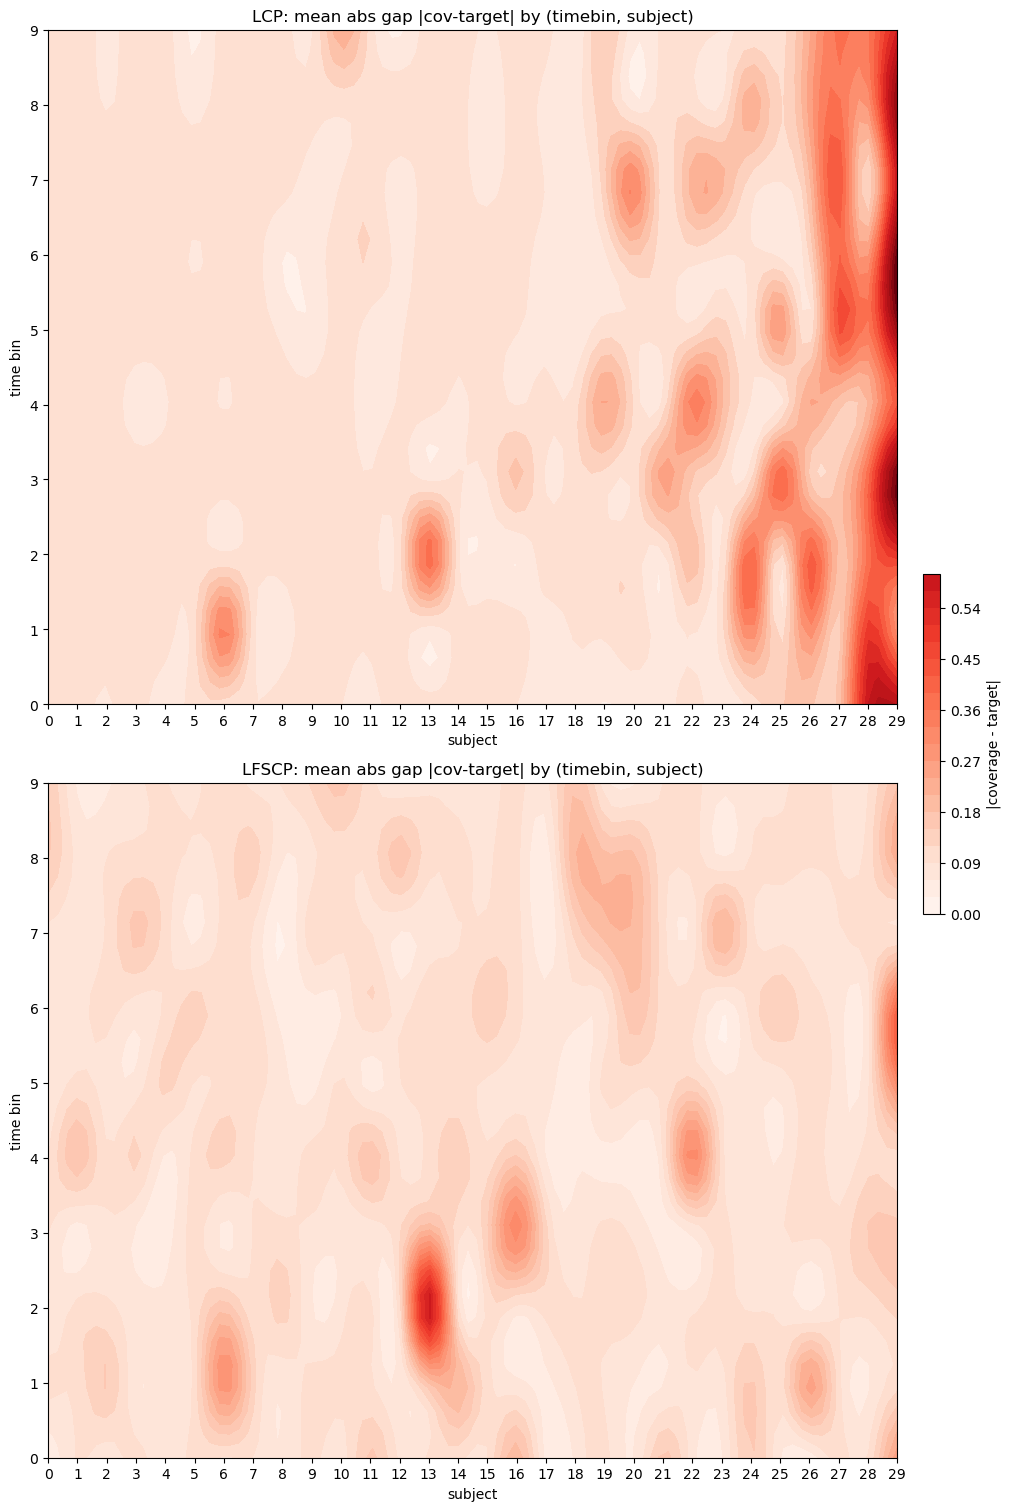

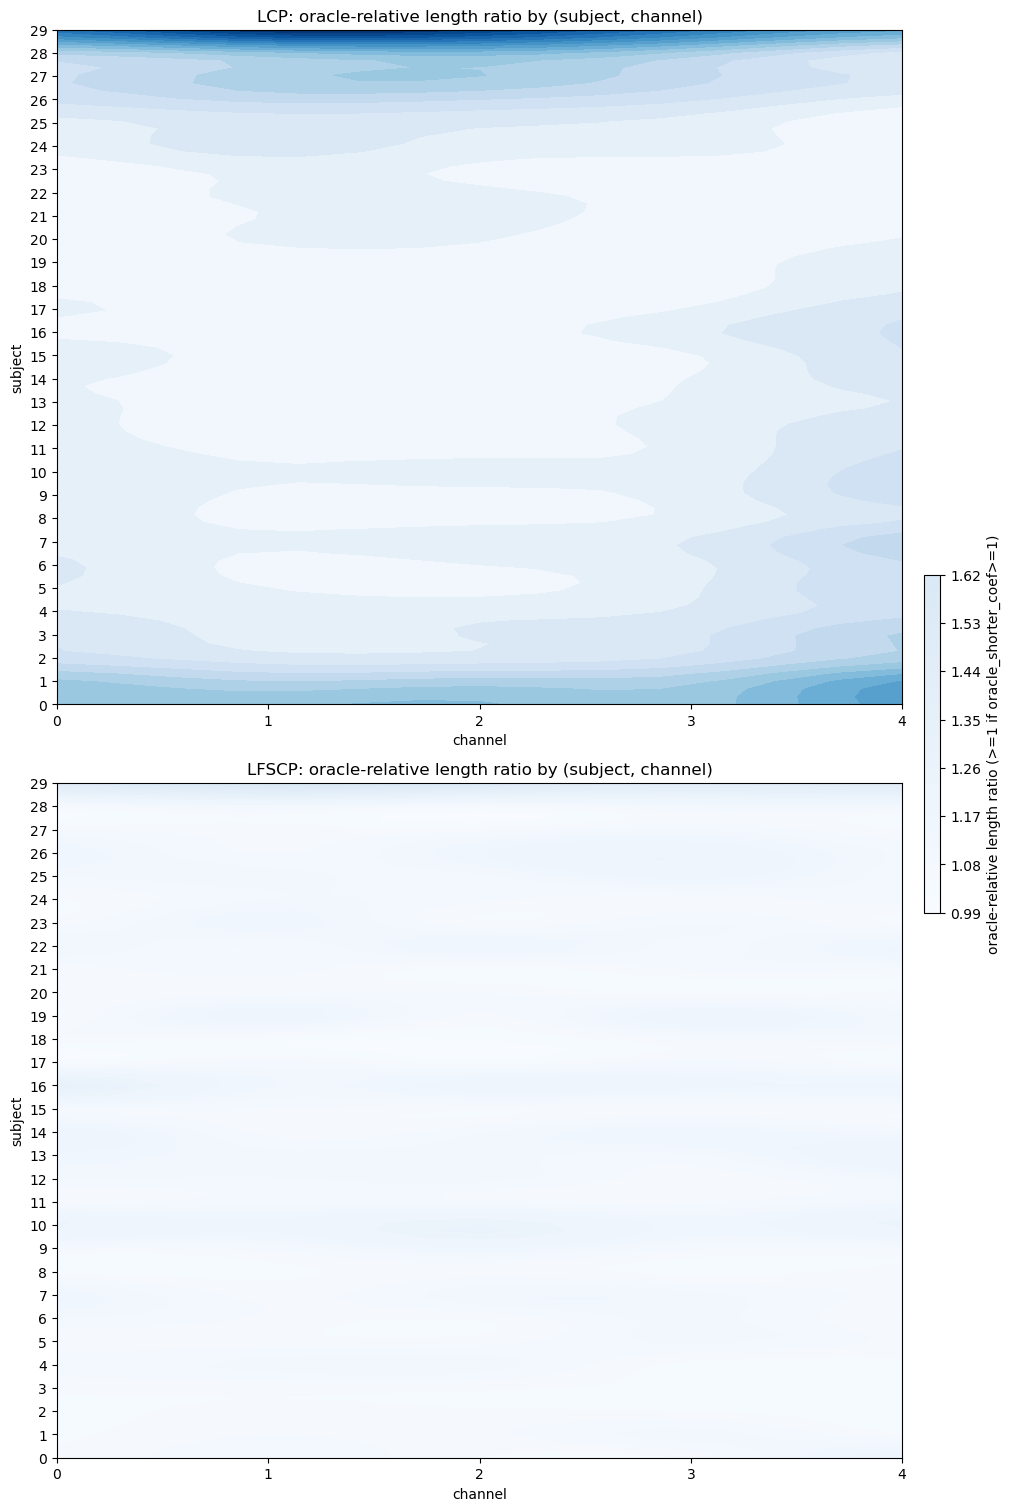

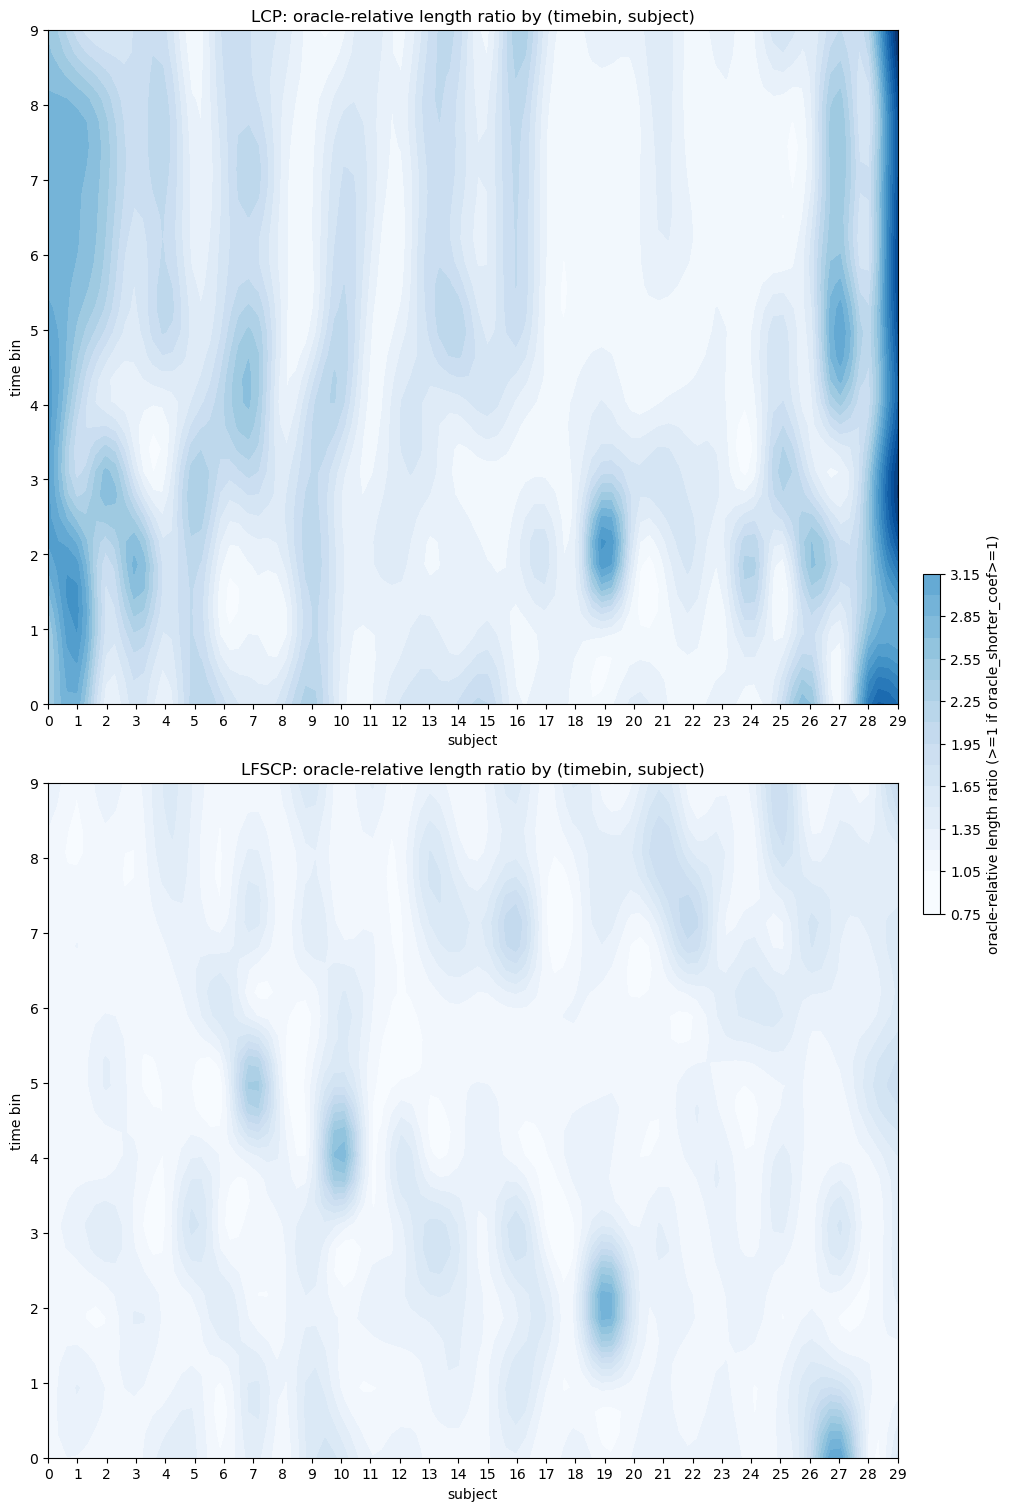

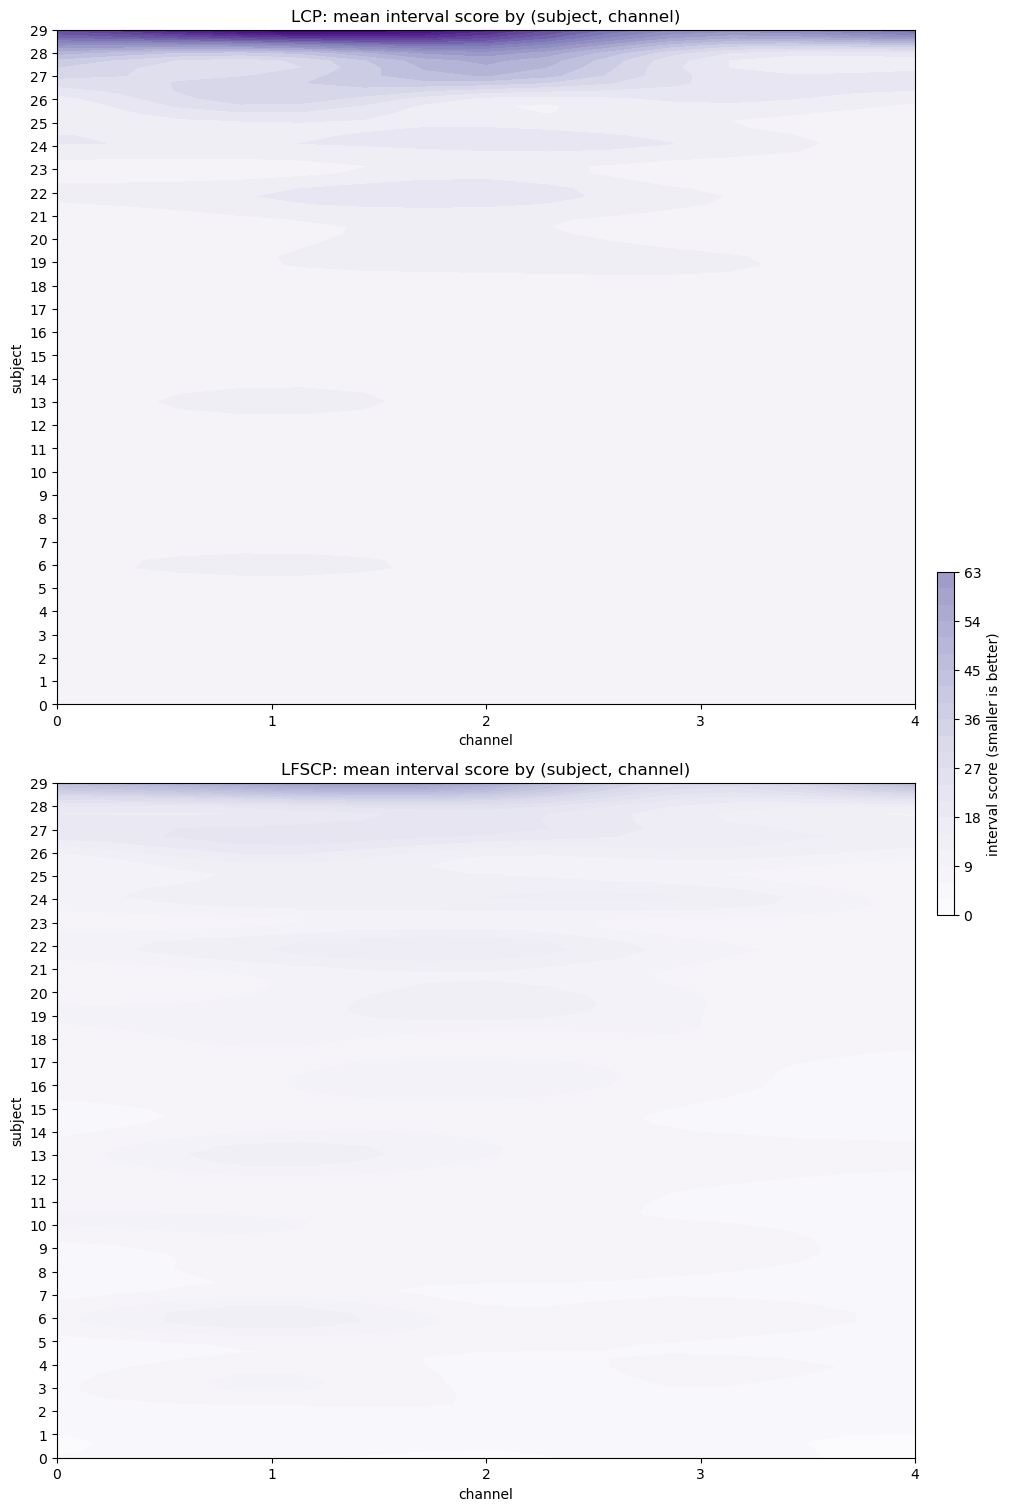

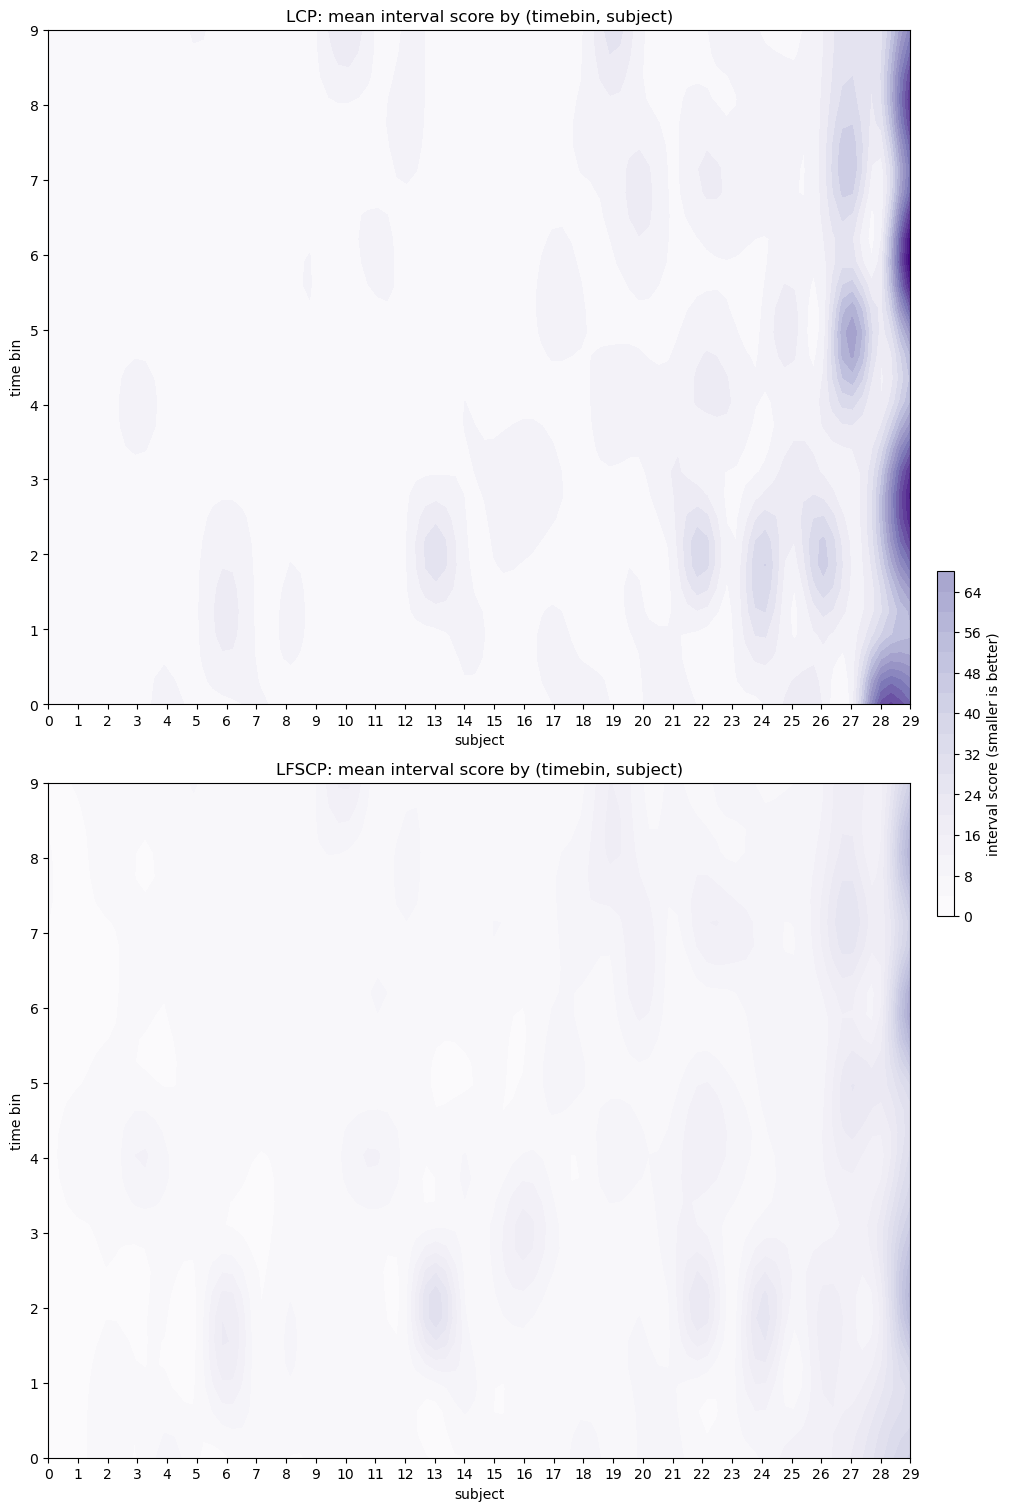

In [146]:
from twfv.plot import plot_compare_conditional_reports_aggregated
from sklearn.linear_model import QuantileRegressor
# importlib.reload(twfv.diagnostics)
from twfv.diagnostics import resample_test_idx_and_collect_scaled_cp_artifacts
if not var_miss:
    P = np.broadcast_to(miss_prob_per_channel, (I, T, J))  # or your per-point P
artifacts = resample_test_idx_and_collect_scaled_cp_artifacts(
    Y=Y,
    train_idx=train_idx,
    p_miss=P,
    sigma_fit_flat=sigma_flat,
    sigma_oracle_flat=sigma_oracle_flat,
    t_res = 10,
    methods=["scp", "tmfv", "oracle", "lcp", "cptdr", "cqr", "decomp"],
    method_kwargs={
        "decomp": {
            "em_result": em_result,
            "factor_mode": "leave_target_out",
            "score_kind": "standardized",
        },
    },
)
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_lcp",
    report_key_b="report_tmfv",
    covered_key_a="covered_lcp",
    covered_key_b="covered_tmfv",
    label_a="LCP",
    label_b="LFSCP",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

In [ ]:
from twfv.plot import plot_compare_conditional_reports_aggregated
from sklearn.linear_model import QuantileRegressor
# importlib.reload(twfv.diagnostics)
from twfv.diagnostics import resample_test_idx_and_collect_scaled_cp_artifacts
if not var_miss:
    P = np.broadcast_to(miss_prob_per_channel, (I, T, J))  # or your per-point P
artifacts = resample_test_idx_and_collect_scaled_cp_artifacts(
    Y=Y,
    train_idx=train_idx,
    p_miss=P,
    sigma_fit_flat=sigma_flat,
    sigma_oracle_flat=sigma_oracle_flat,
    t_res = 20,
    methods=["scp", "tmfv", "oracle", "lcp", "cptdr", "cqr", "decomp"],
    method_kwargs={
        "decomp": {
            "em_result": em_result,
            "factor_mode": "leave_target_out",
            "score_kind": "standardized",
        },
    },
)
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_lcp",
    report_key_b="report_tmfv",
    covered_key_a="covered_lcp",
    covered_key_b="covered_tmfv",
    label_a="LCP",
    label_b="LFSCP",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

In [ ]:
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_tmfv",
    report_key_b="report_decomp",
    covered_key_a="covered_tmfv",
    covered_key_b="covered_decomp",
    label_a="LFSCP",
    label_b="Decomp",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

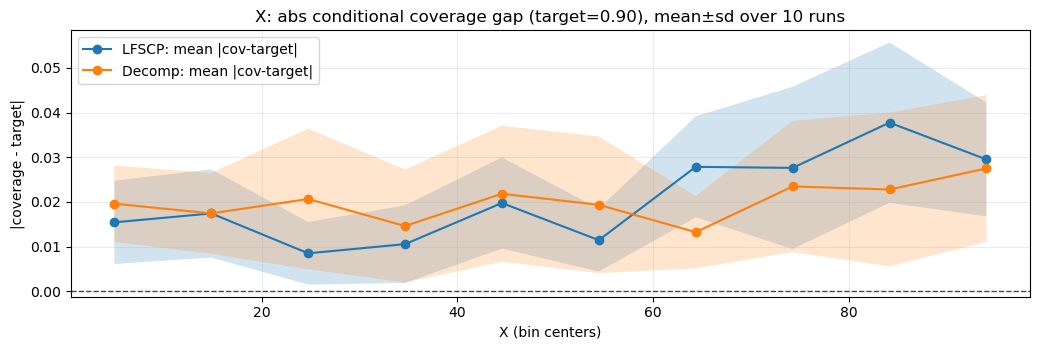

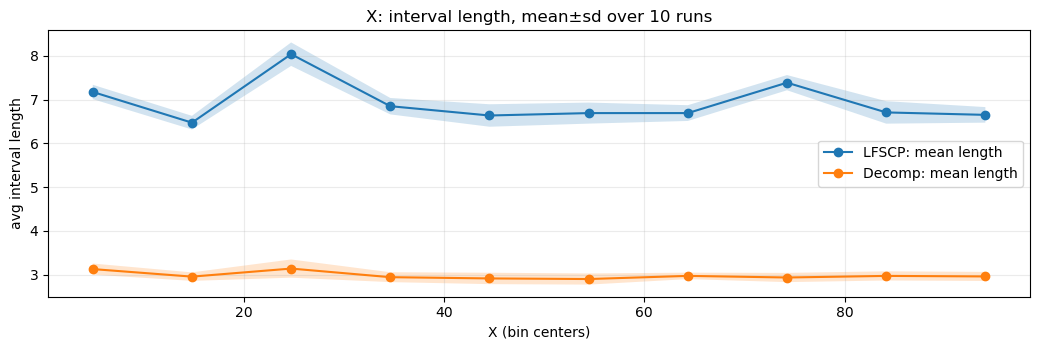

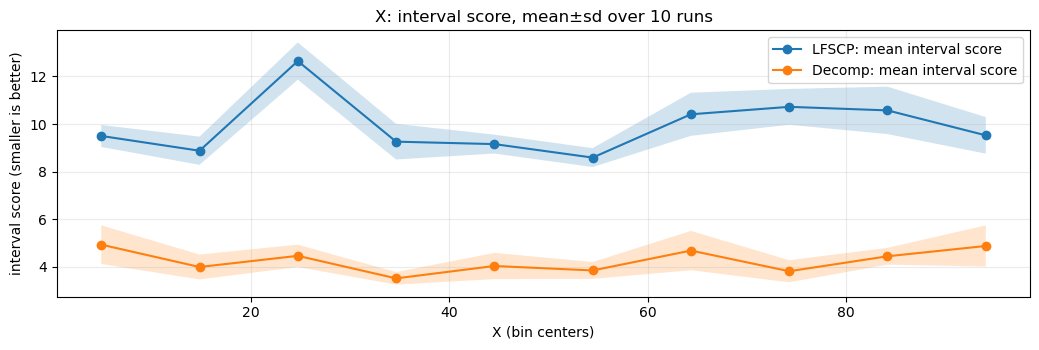

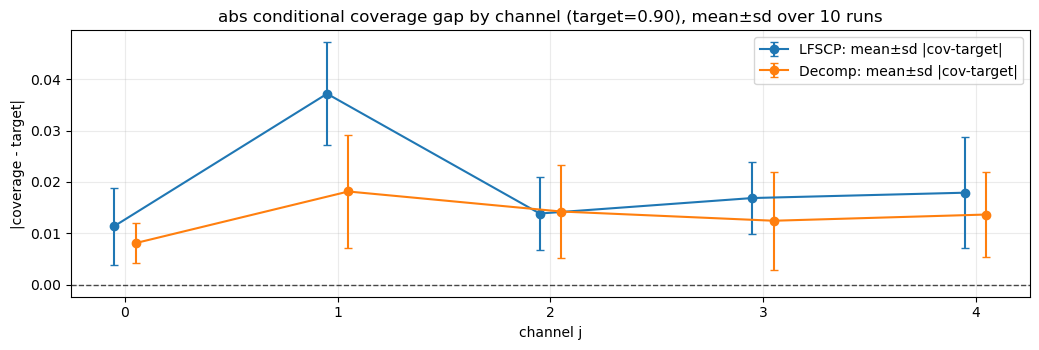

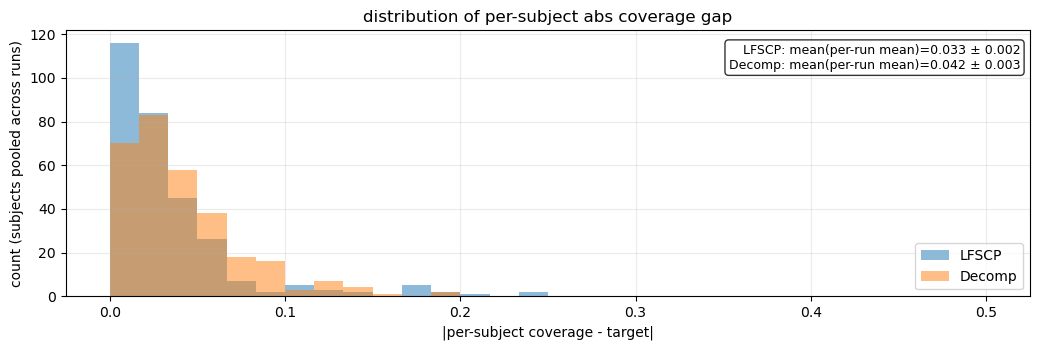

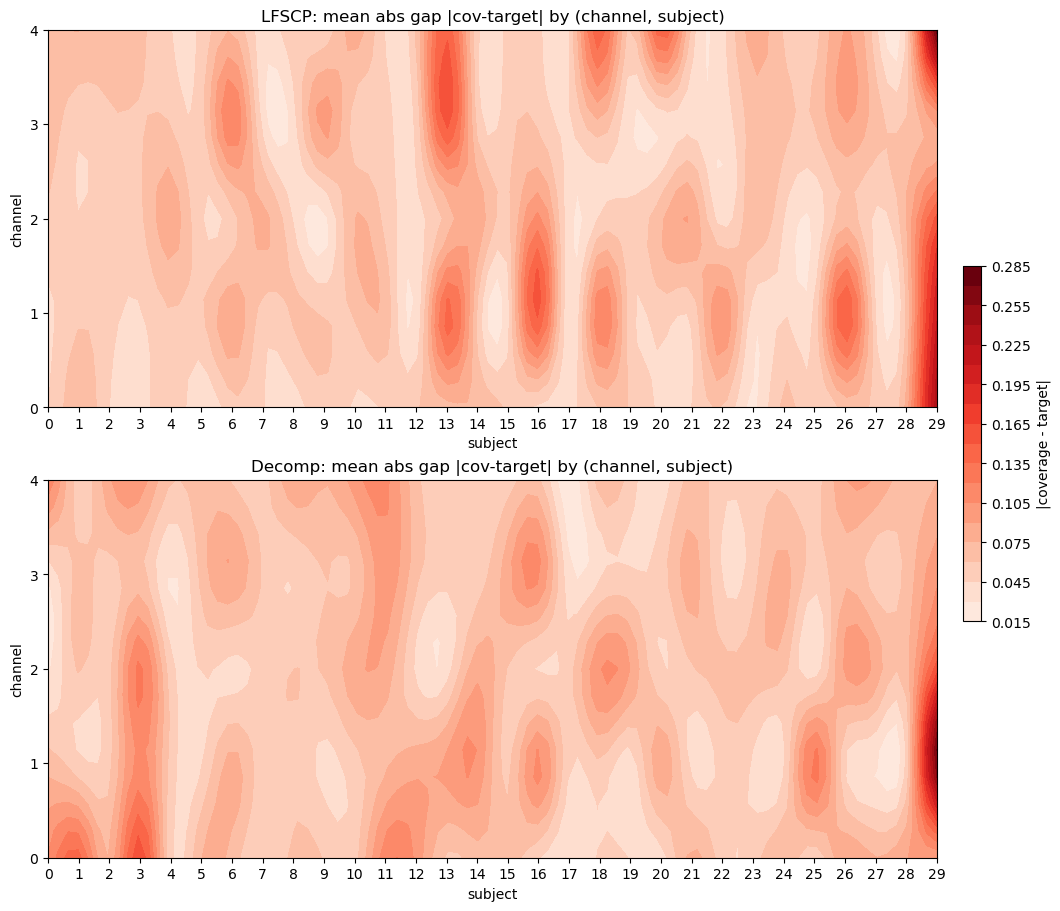

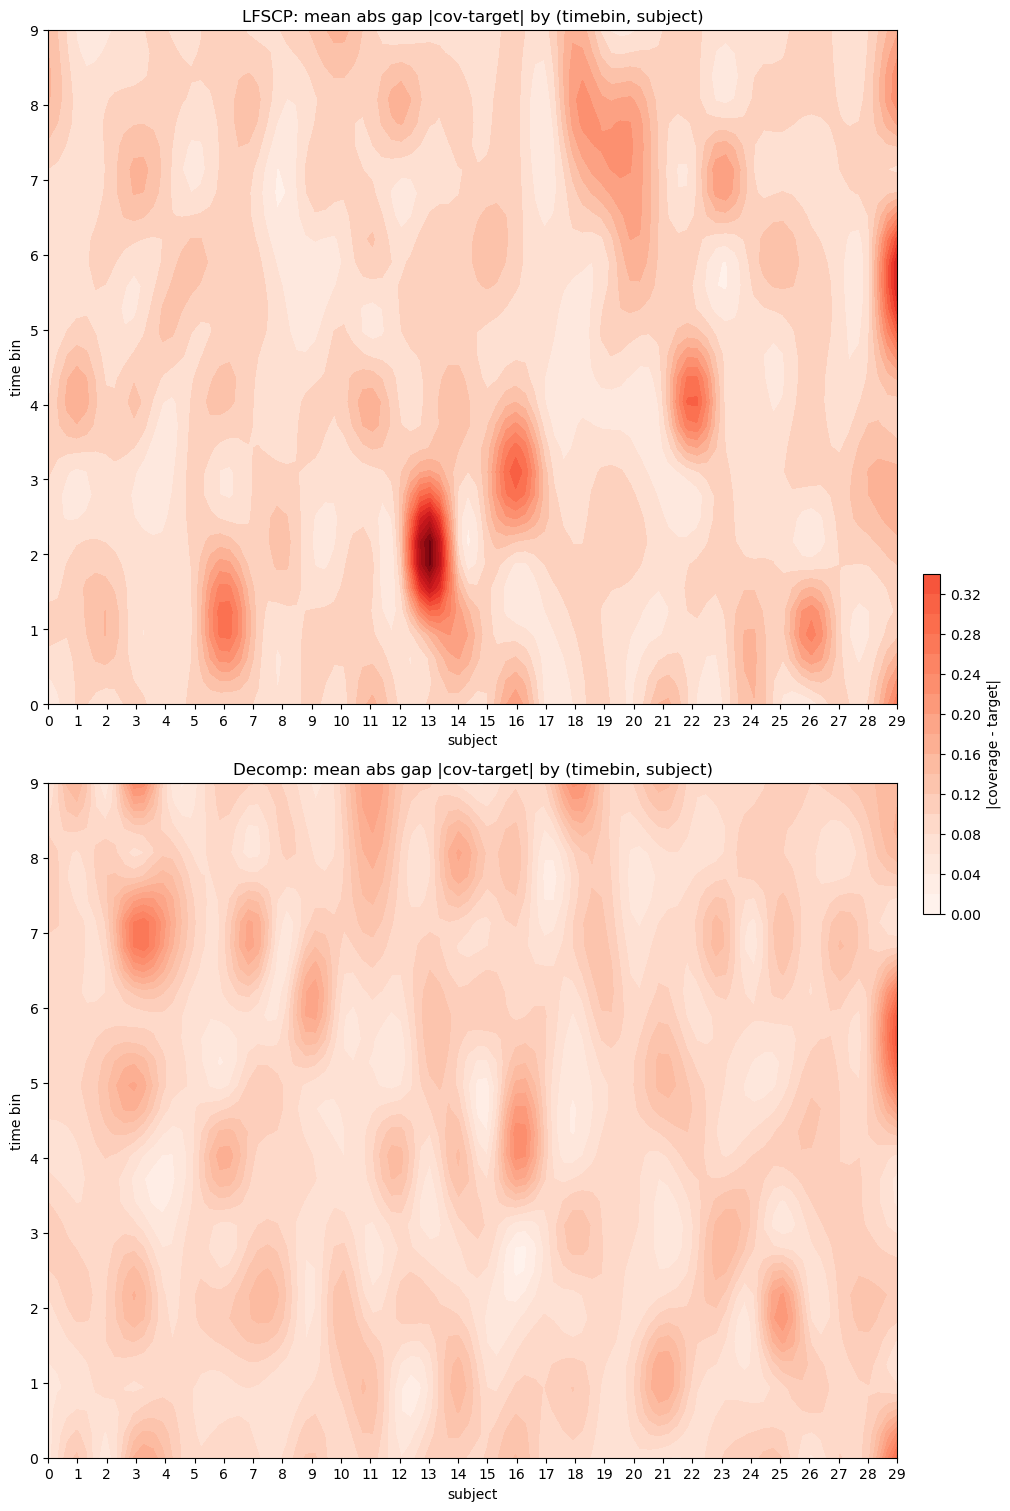

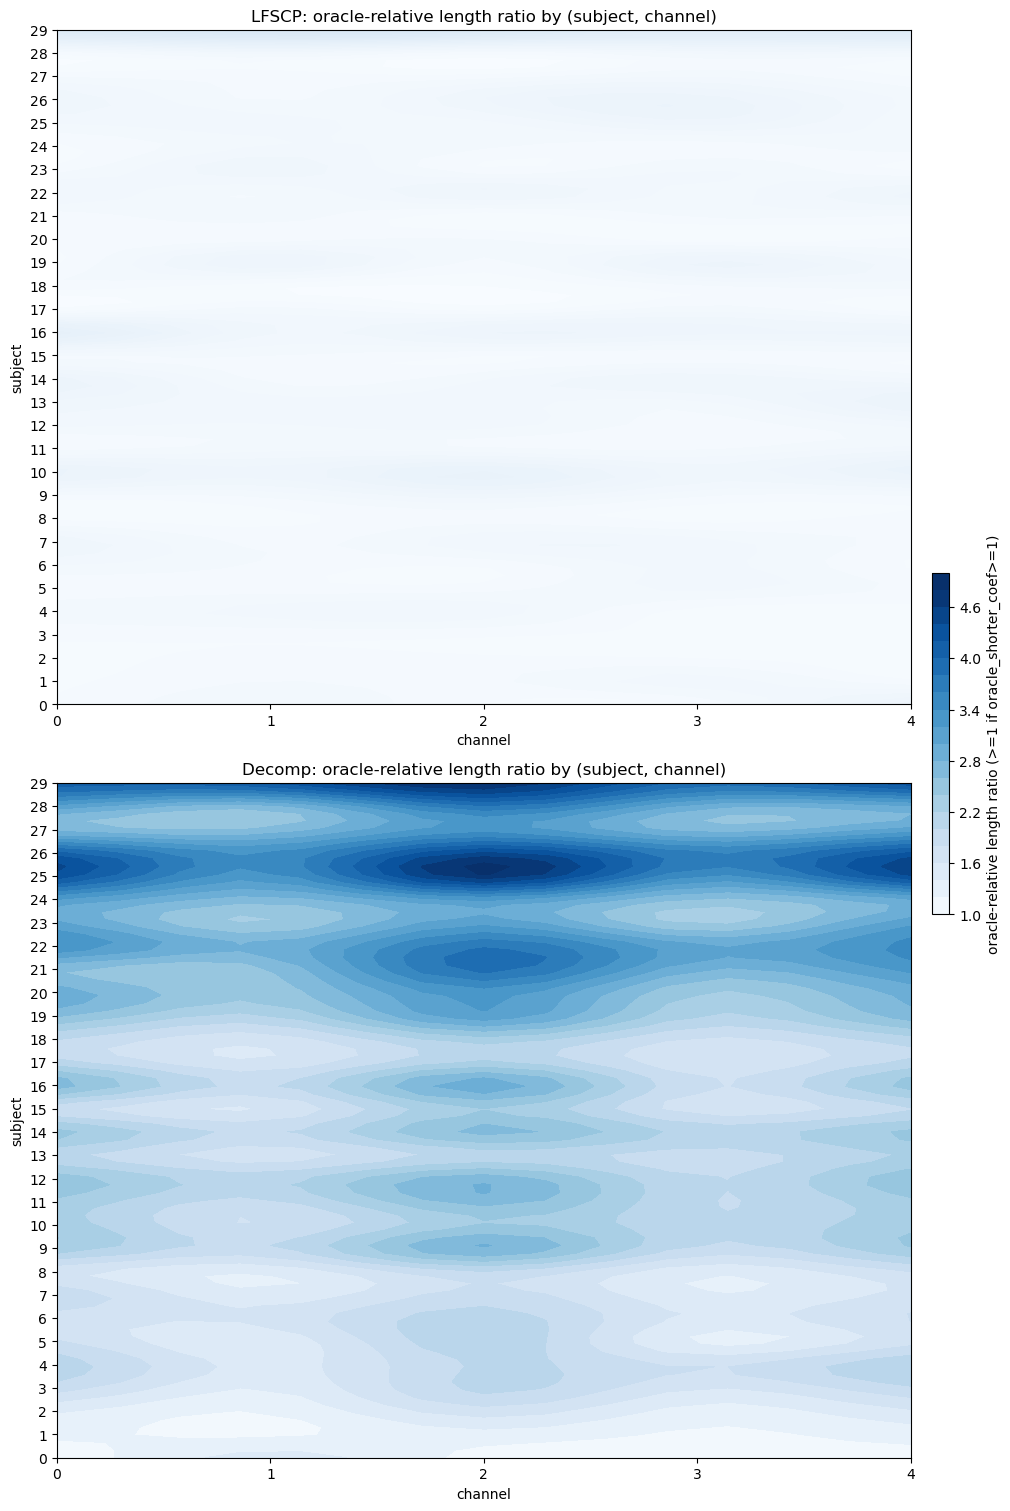

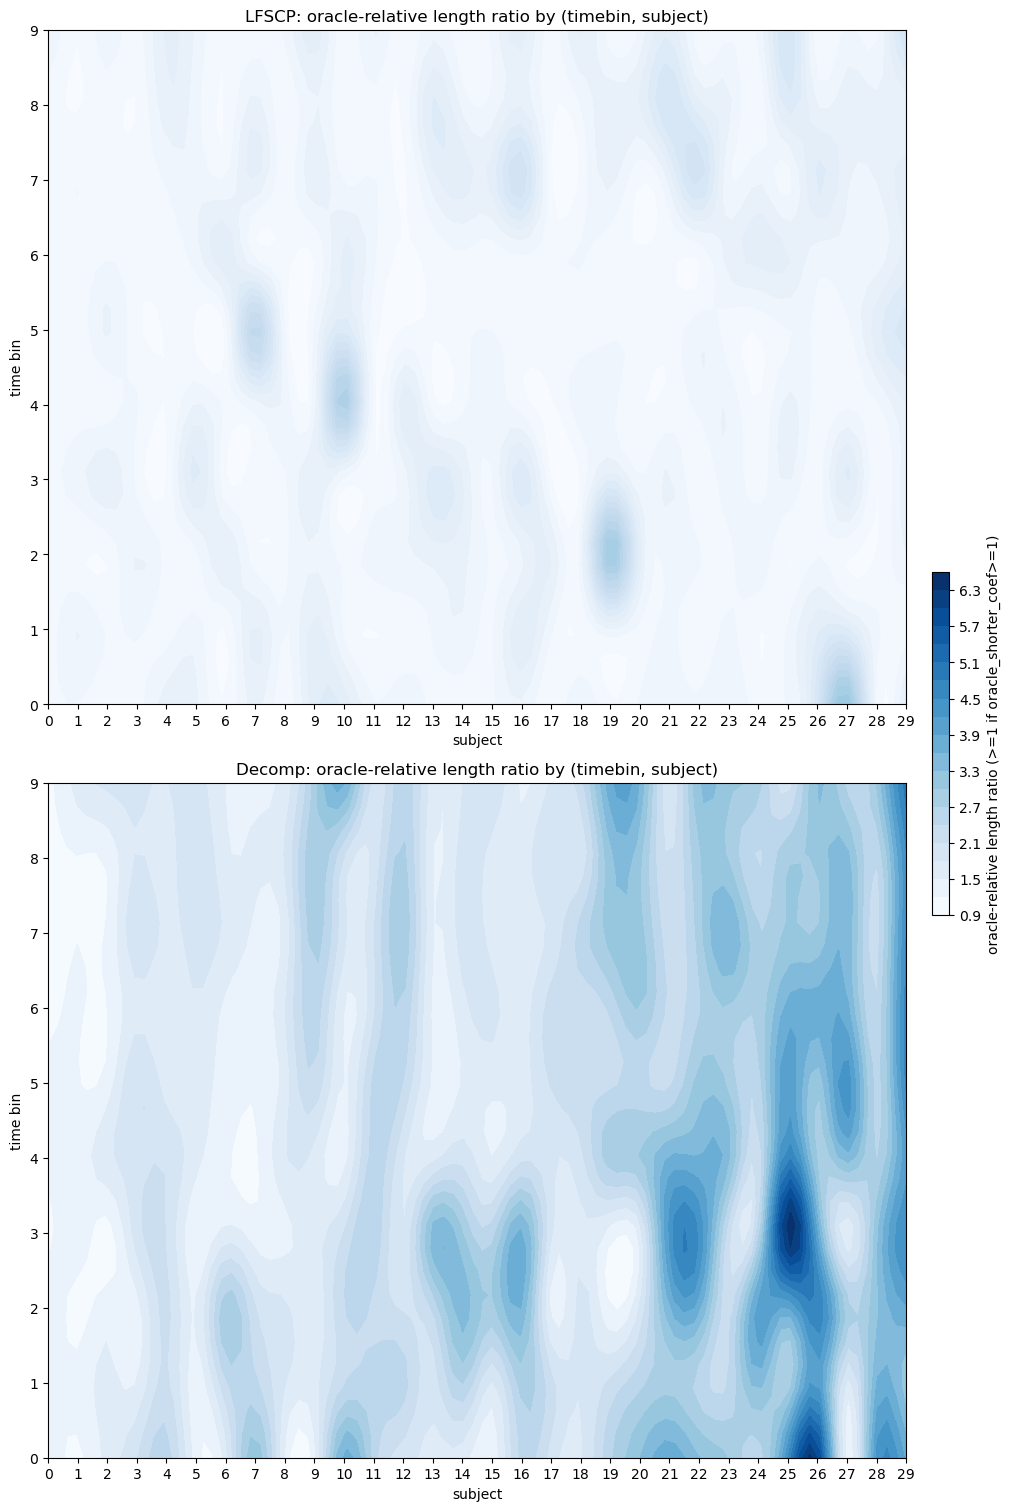

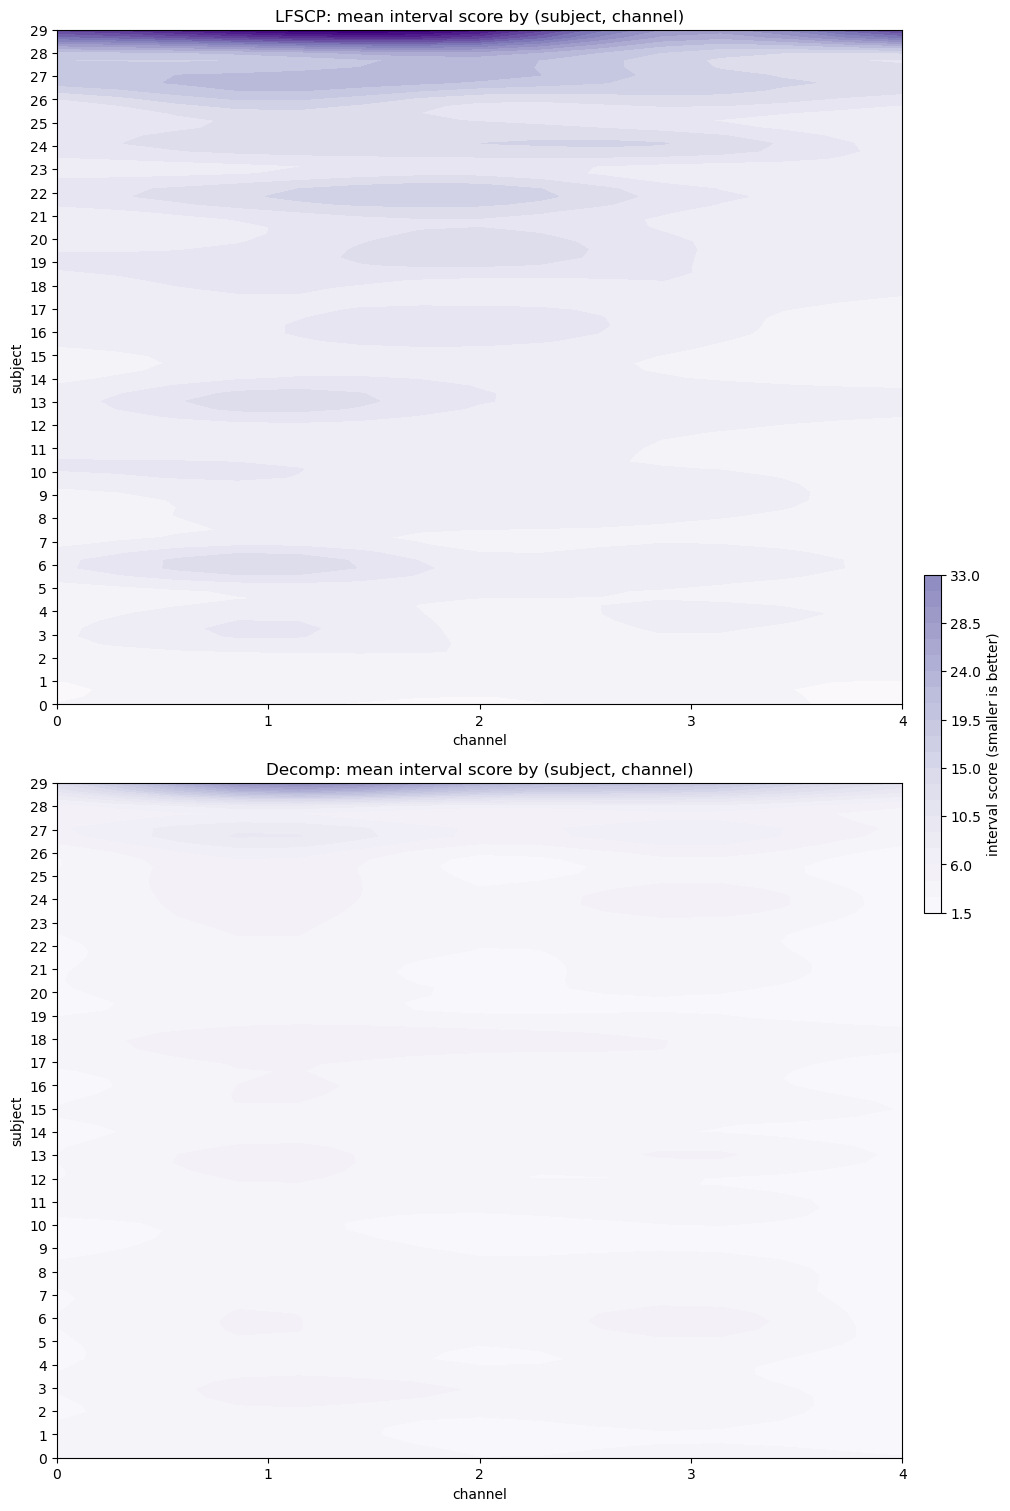

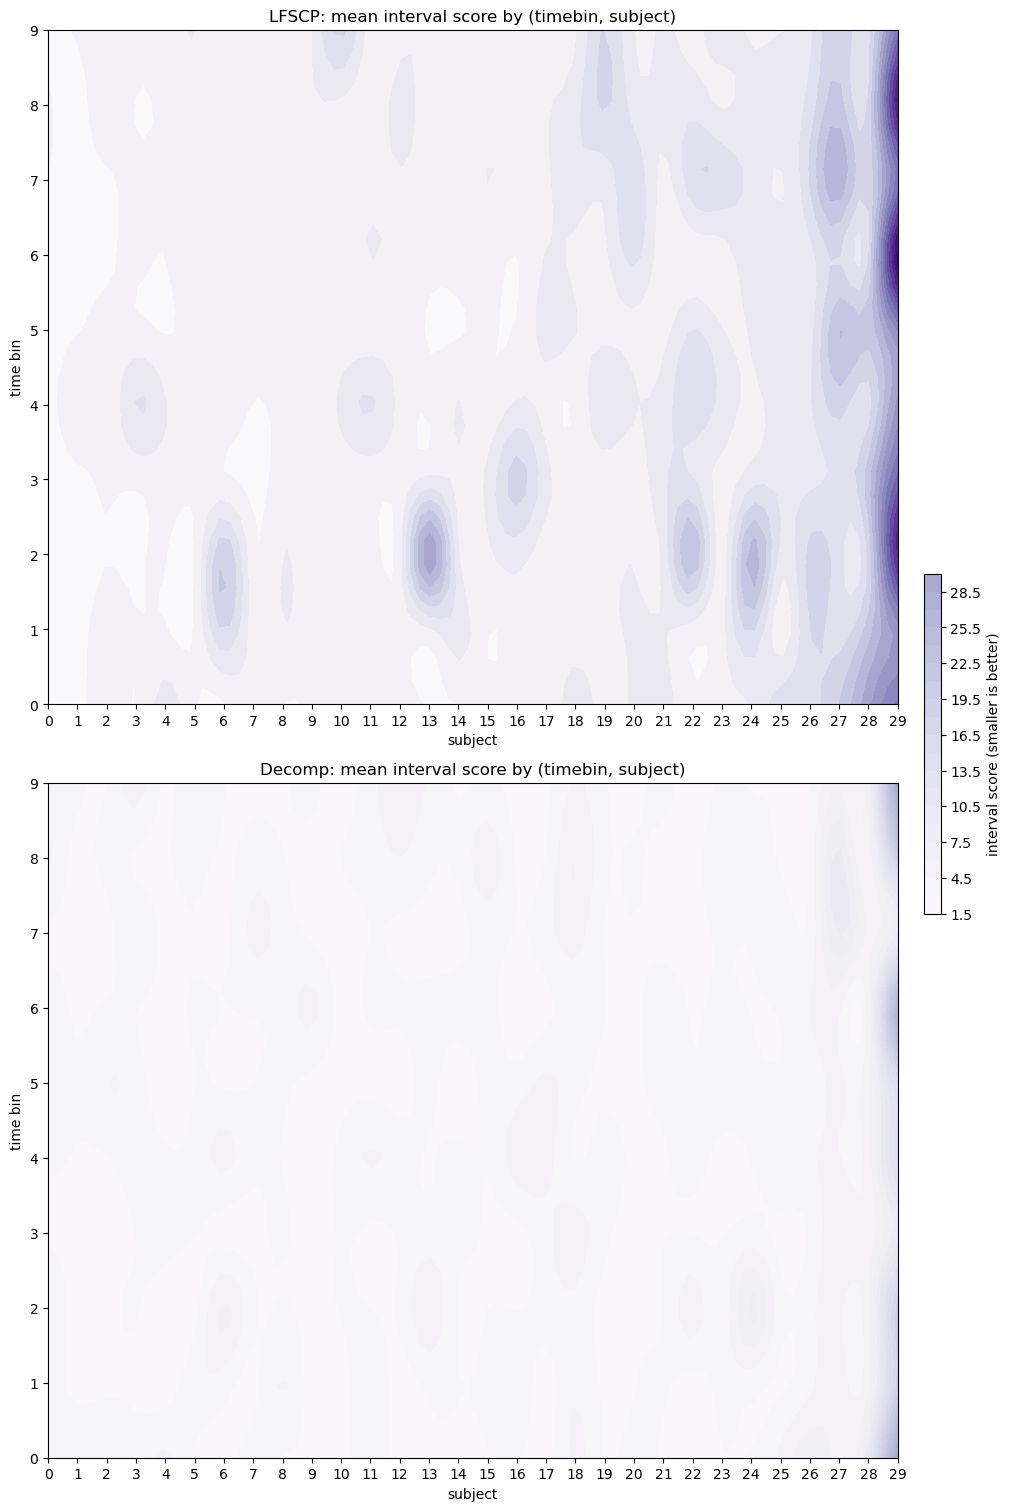

In [147]:
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_tmfv",
    report_key_b="report_decomp",
    covered_key_a="covered_tmfv",
    covered_key_b="covered_decomp",
    label_a="LFSCP",
    label_b="Decomp",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

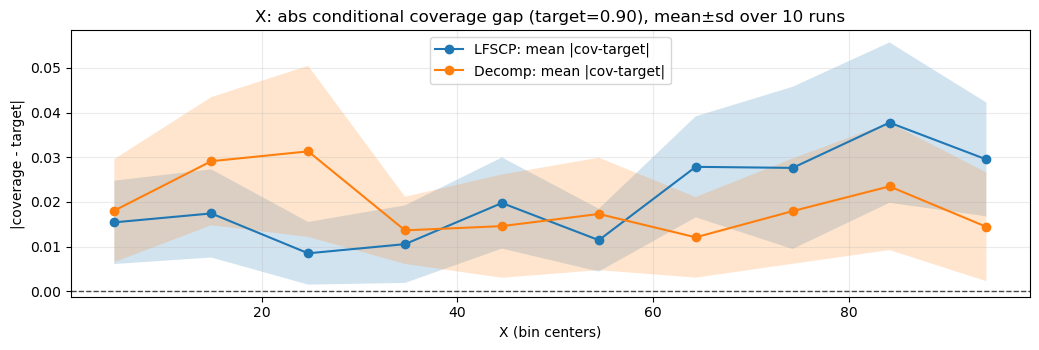

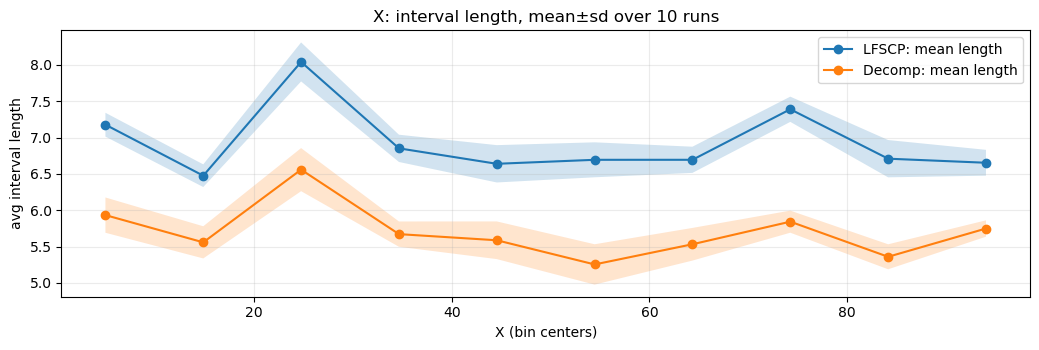

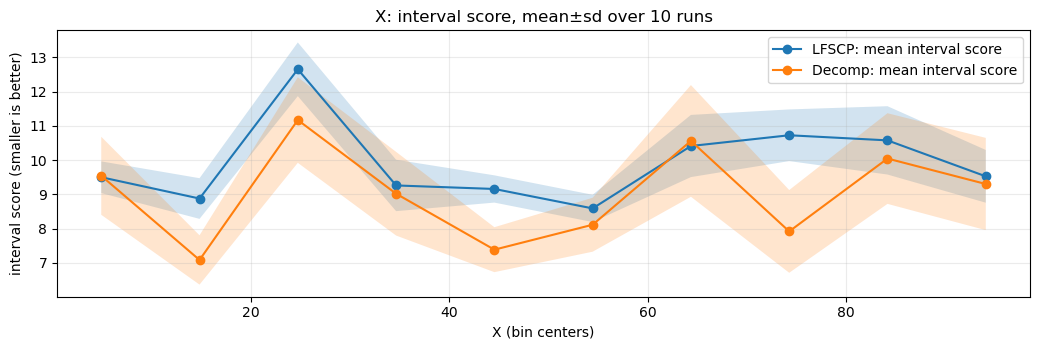

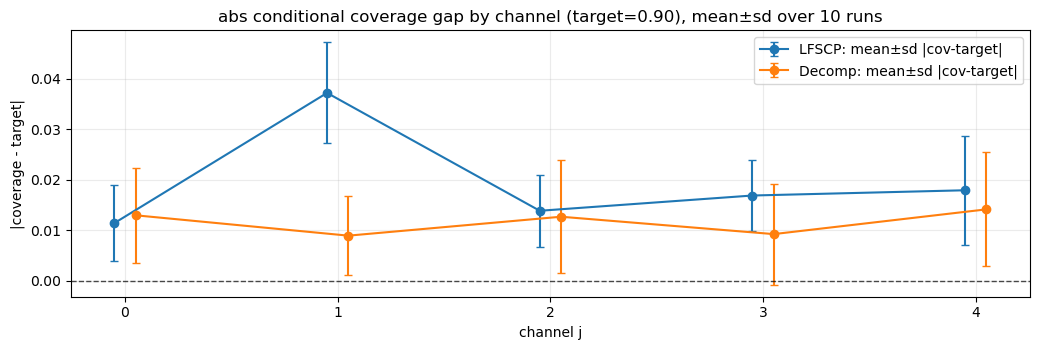

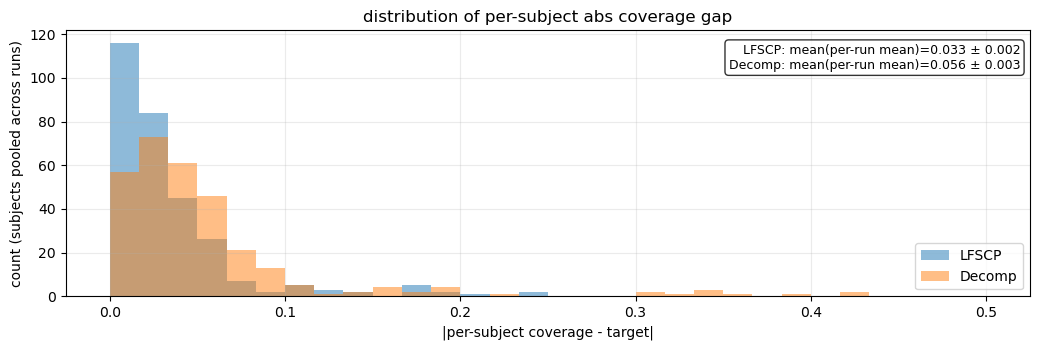

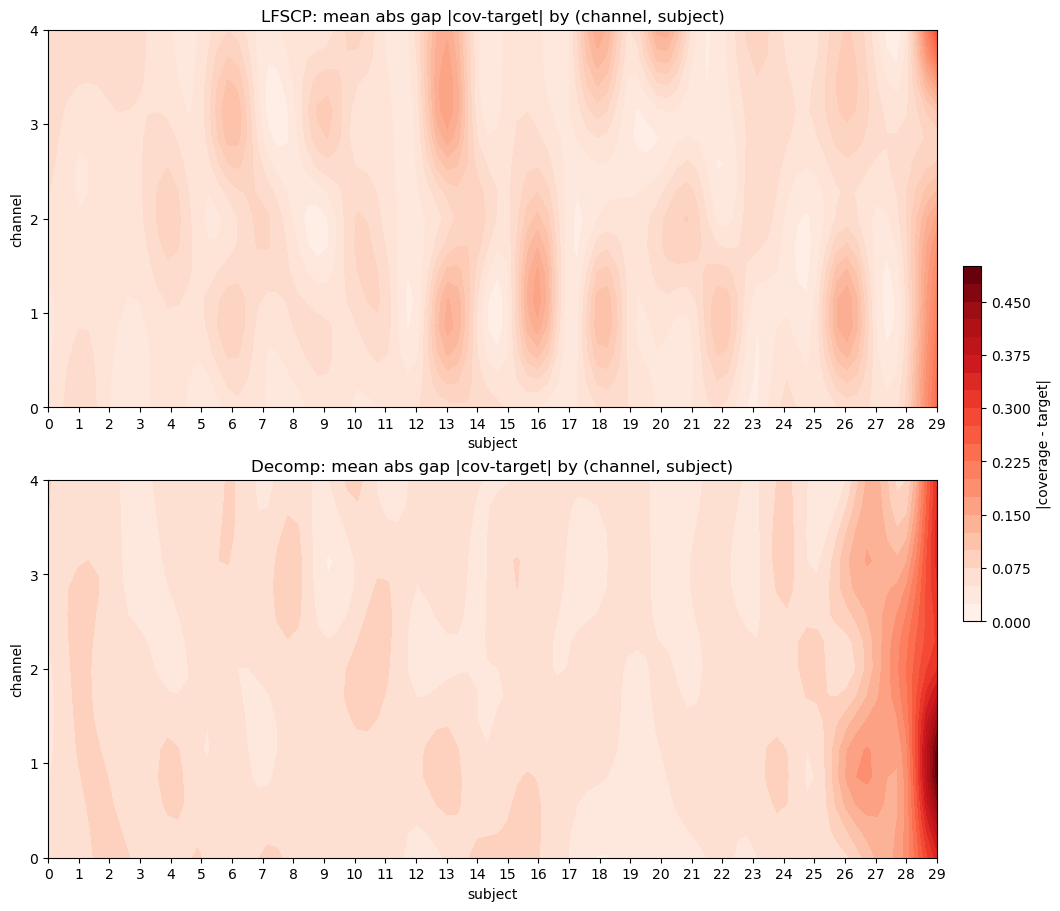

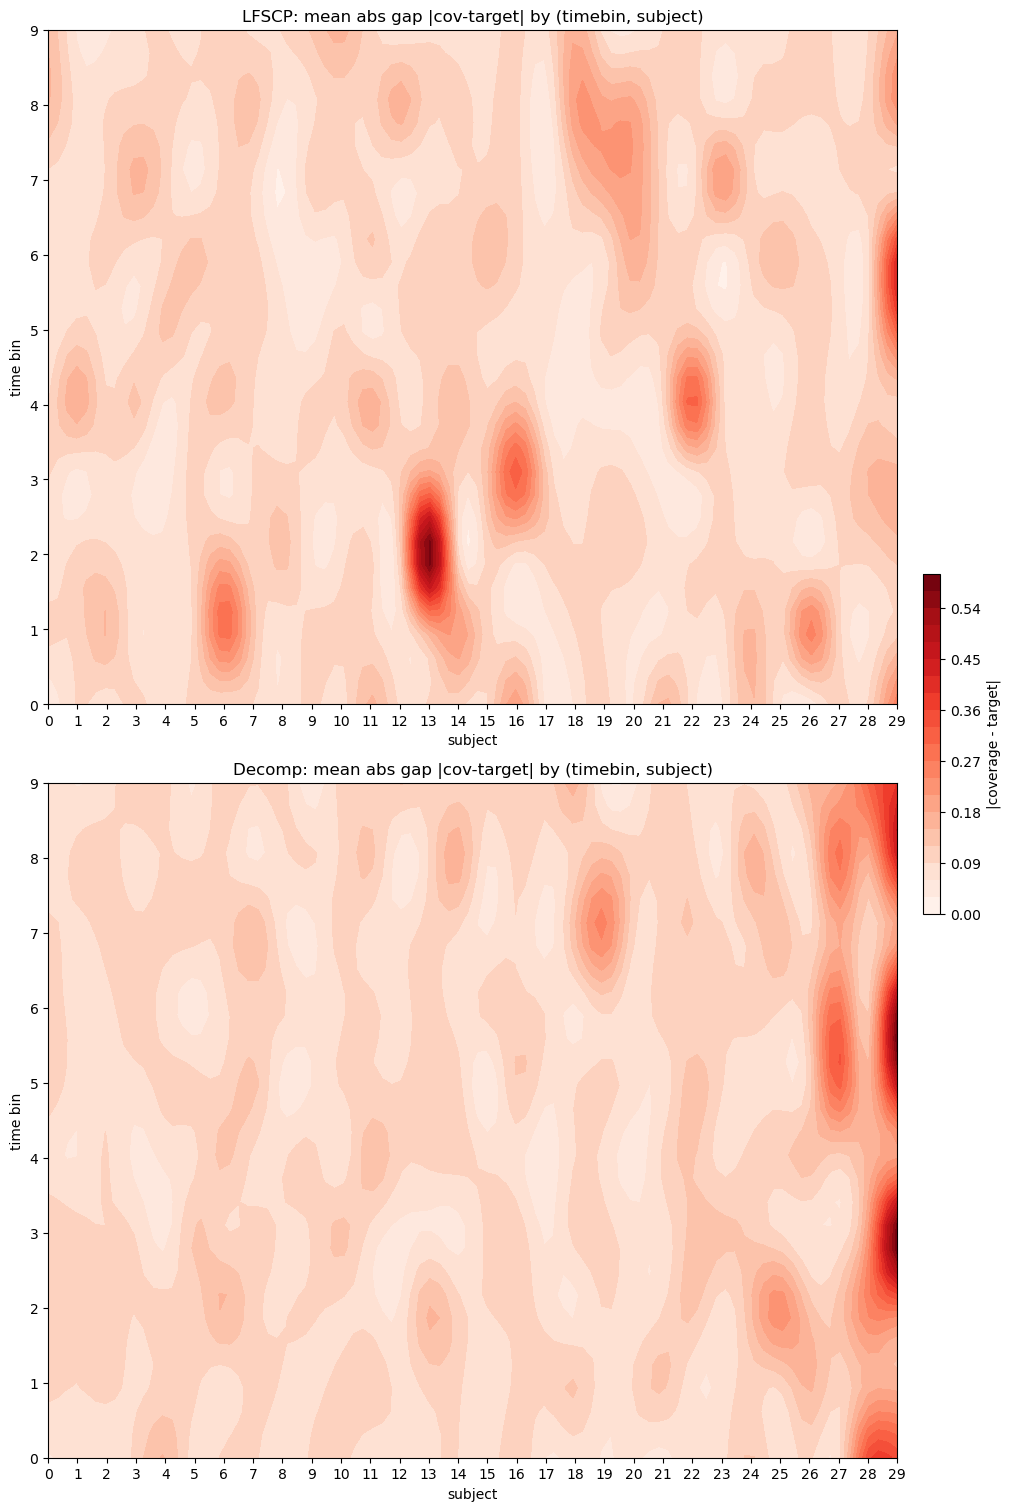

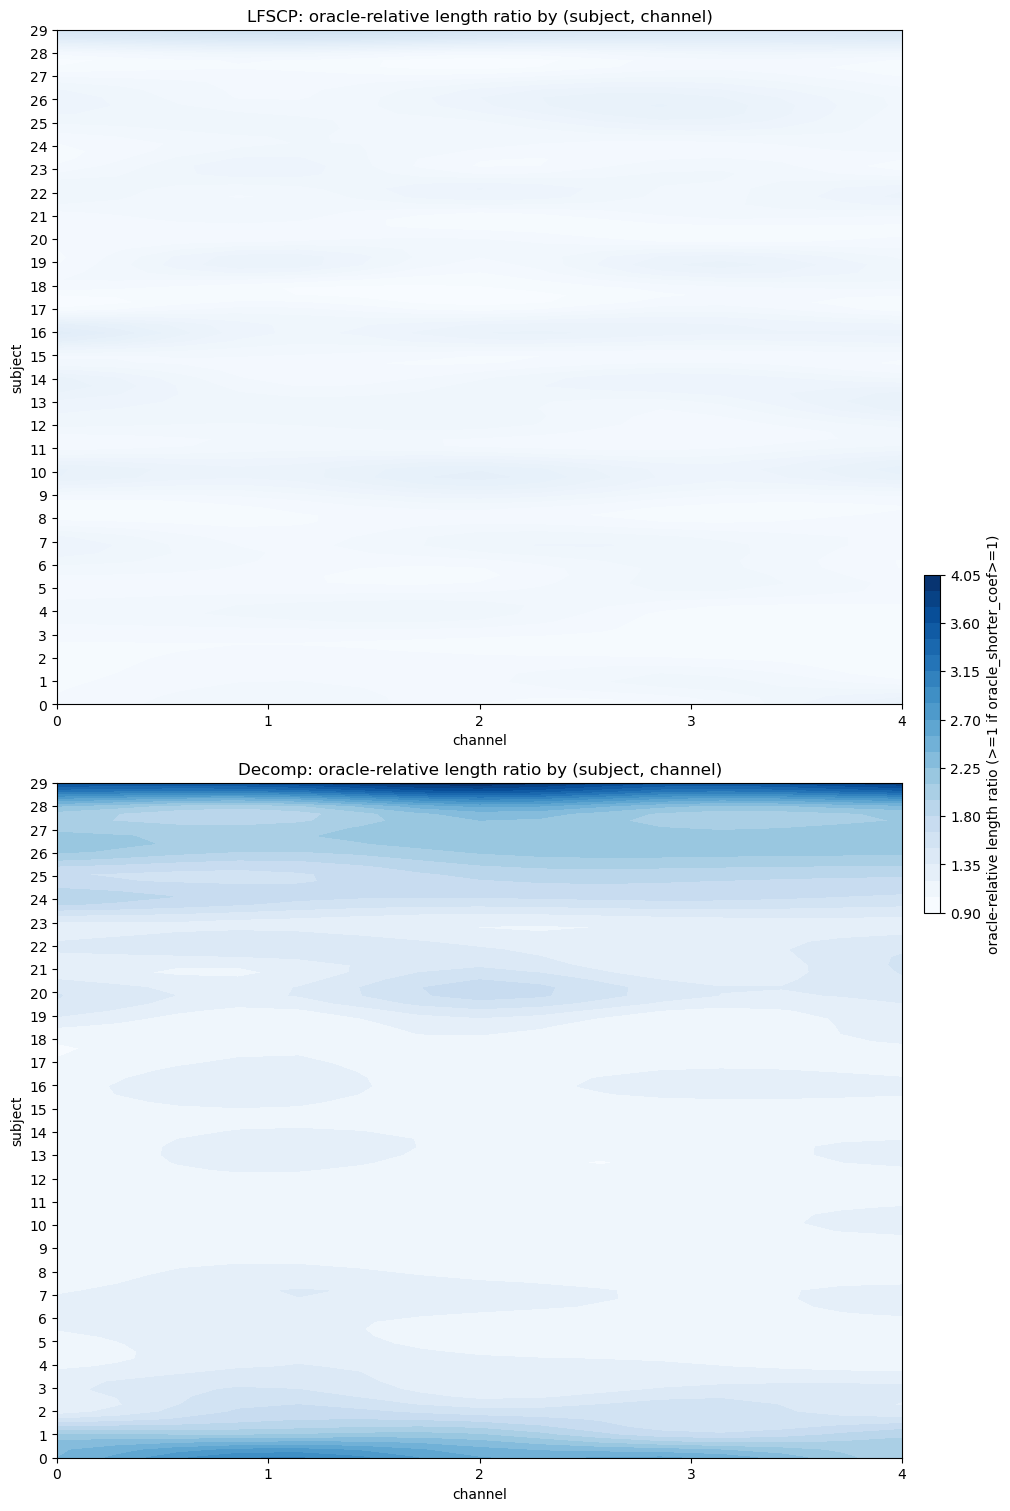

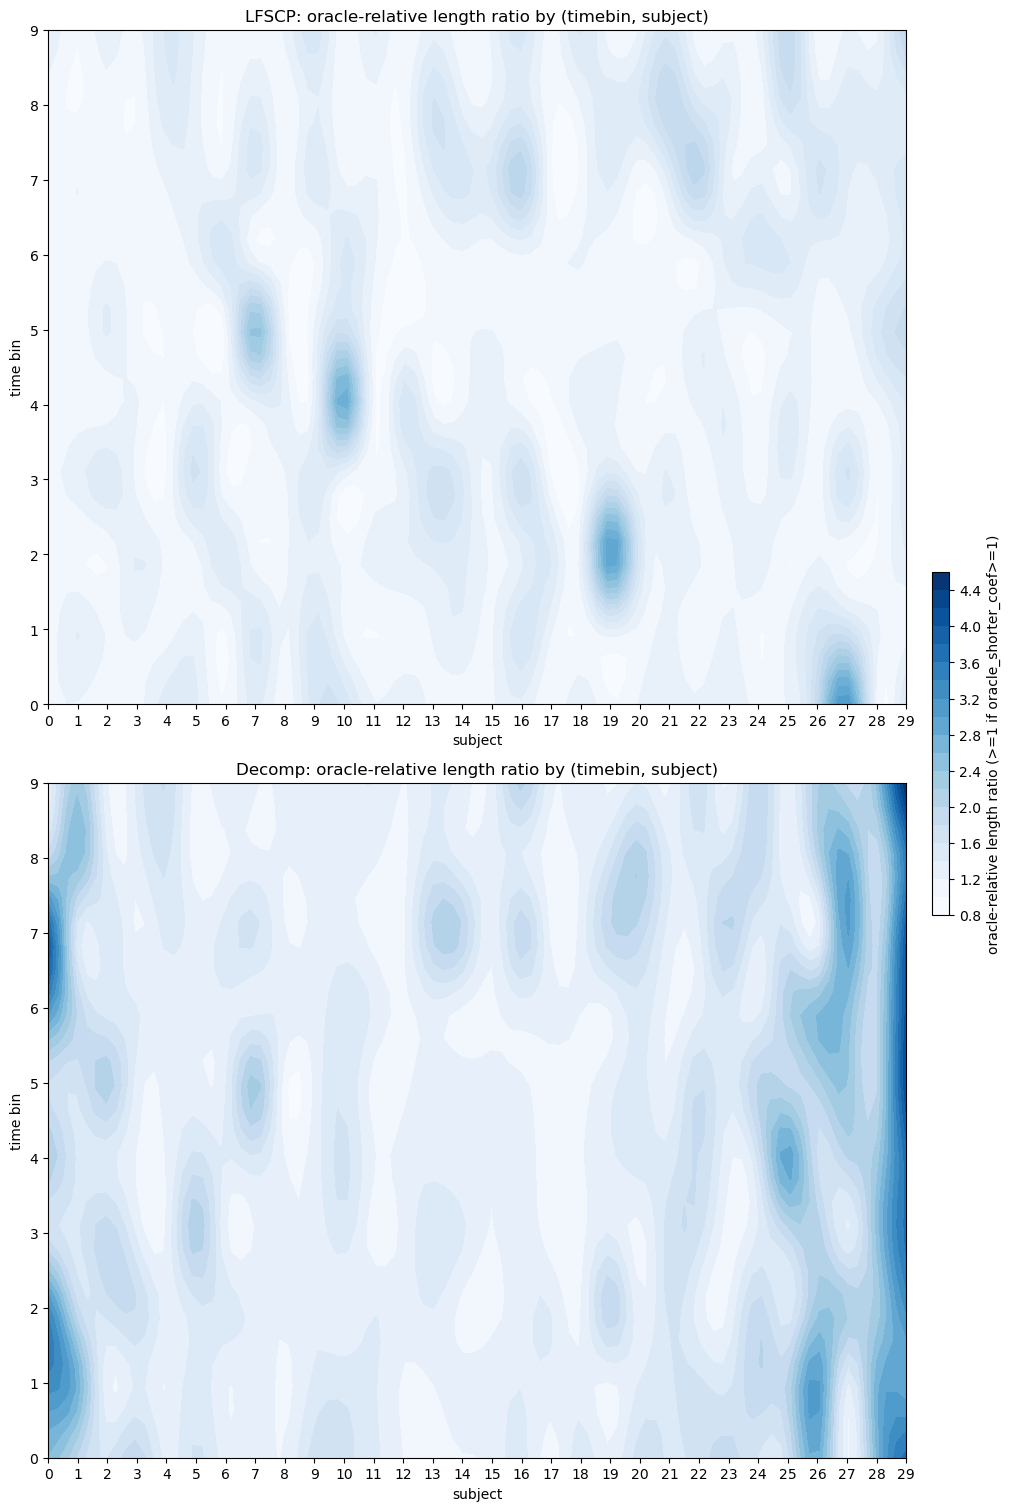

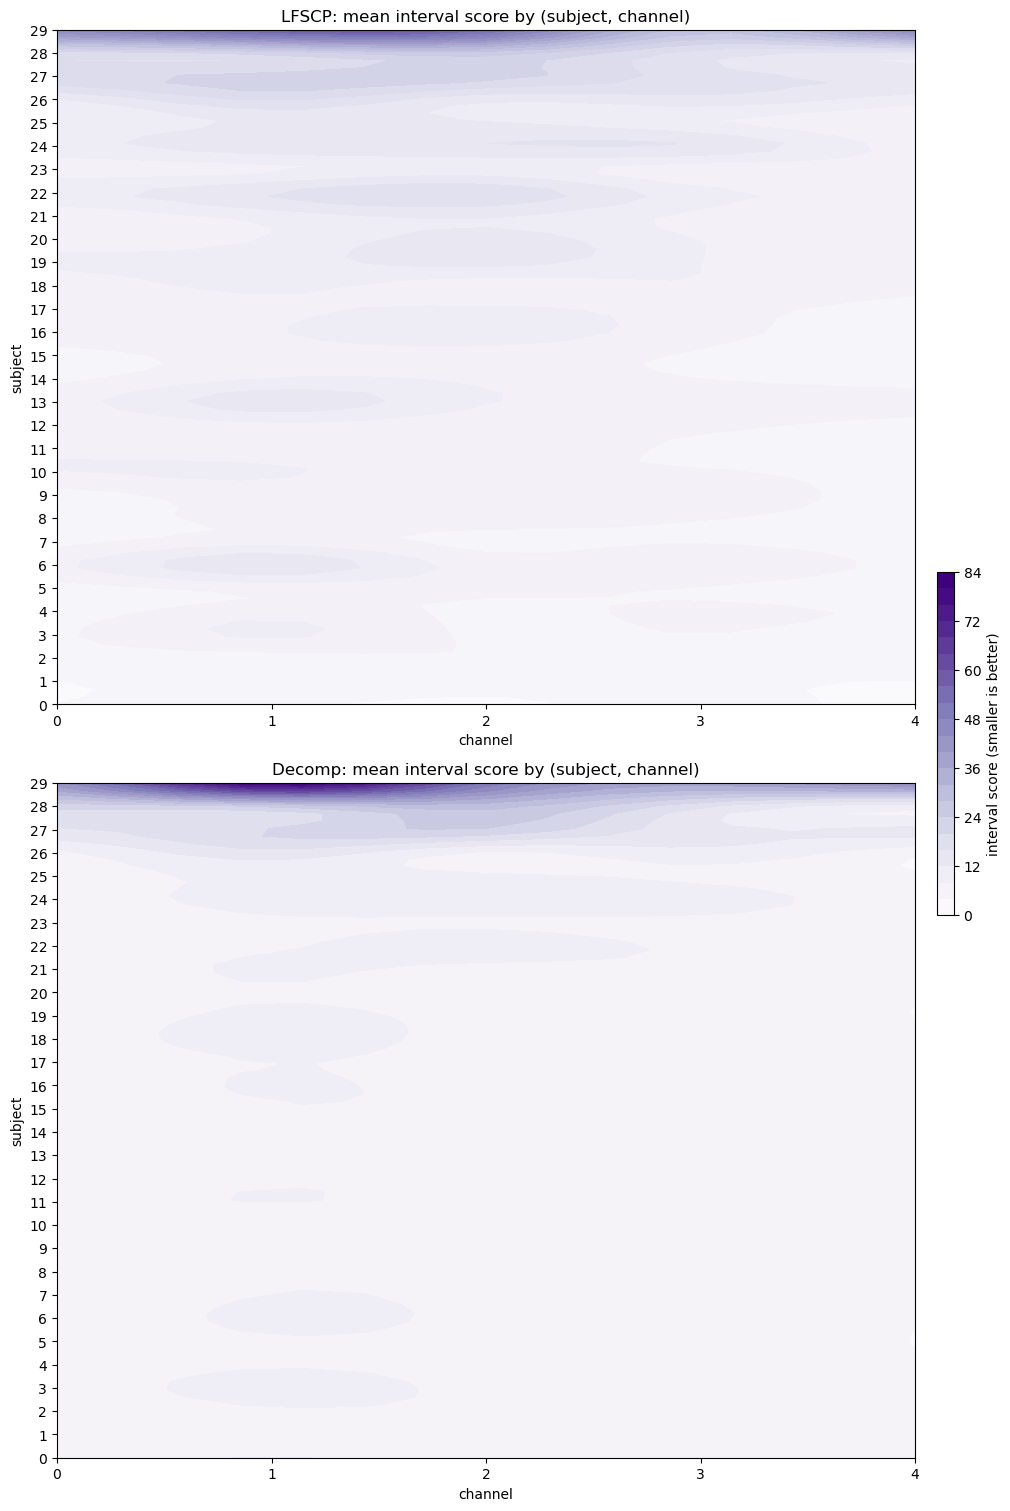

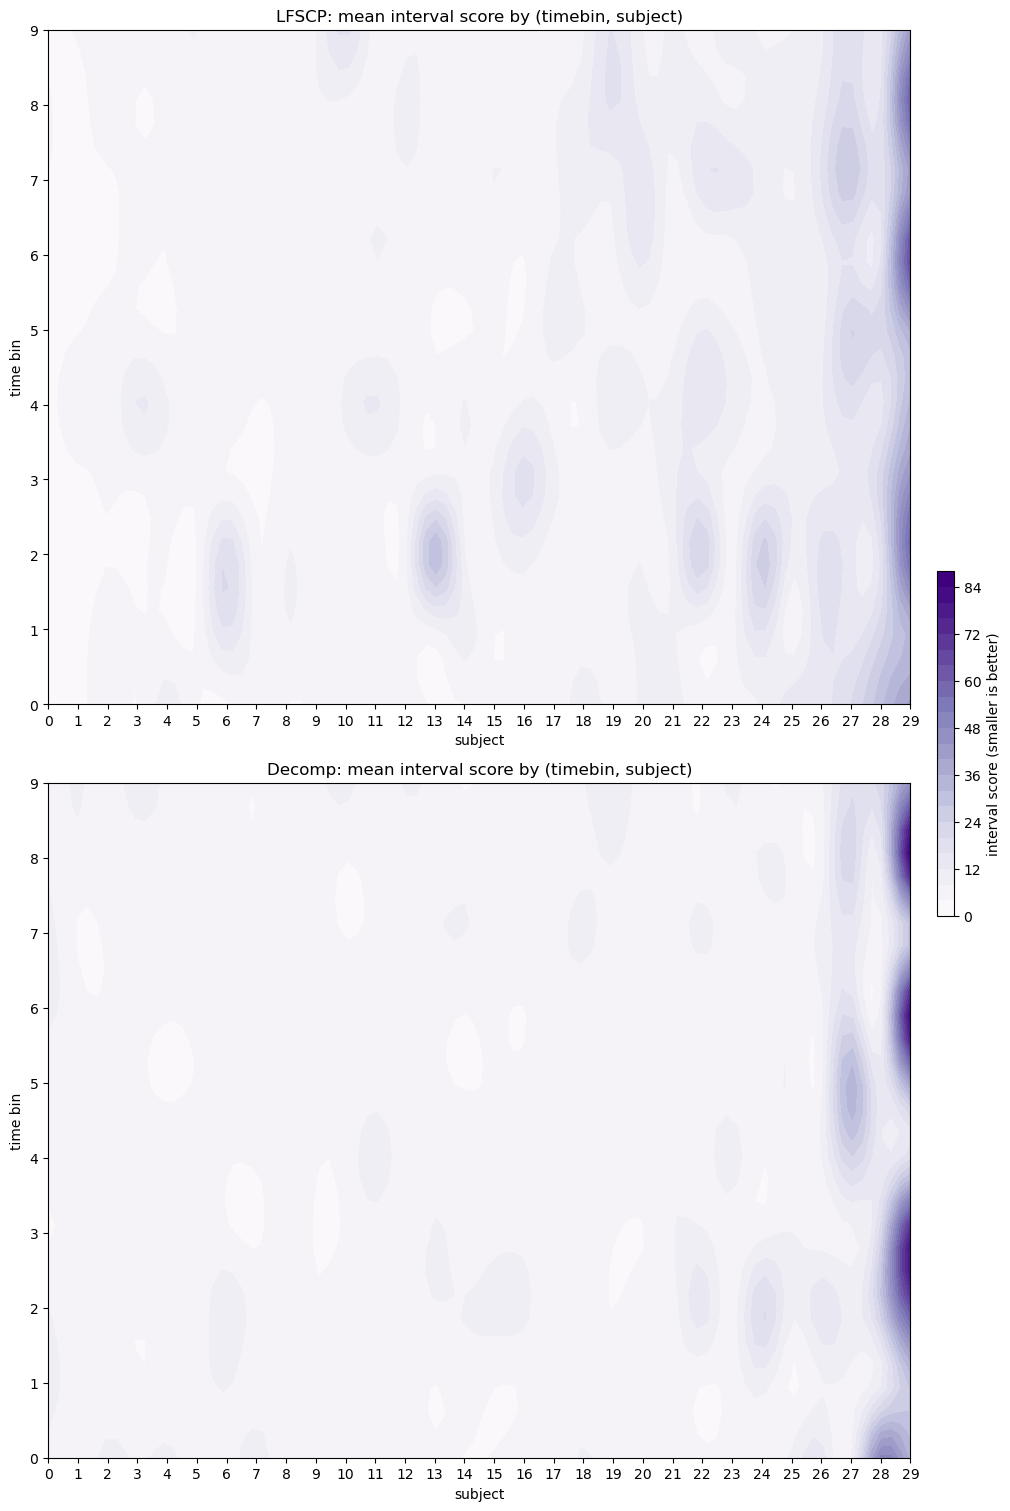

In [170]:
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_tmfv",
    report_key_b="report_decomp",
    covered_key_a="covered_tmfv",
    covered_key_b="covered_decomp",
    label_a="LFSCP",
    label_b="Decomp",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

In [23]:
delta_q=np.array([artifacts[i]["delta_q"] for i in range(len(artifacts))])
mu = delta_q.mean()
se = delta_q.std(ddof=1)/np.sqrt(len(delta_q))
ci = (mu - 1.96*se, mu + 1.96*se)
print(f'mu: {mu:.4f}, se: {se:.4f}, ci: {list(np.round(ci,4))}')

mu: -0.1105, se: 0.0070, ci: [-0.1242, -0.0967]


In [27]:
import importlib
import twfv
importlib.reload(twfv.plot)

<module 'twfv.plot' from 'j:\\research\\TWFVconformal\\twfv\\plot.py'>

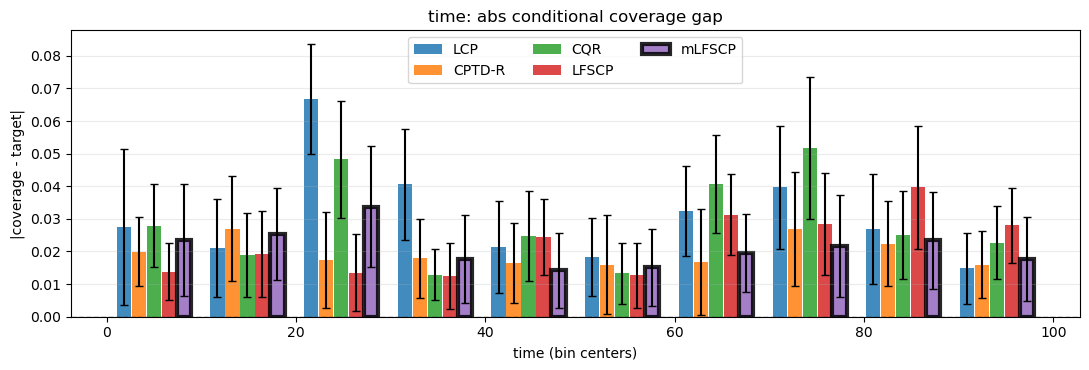

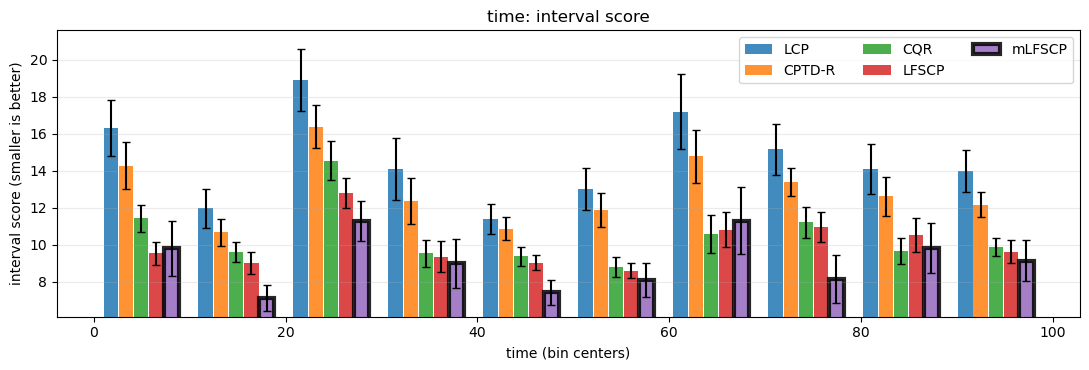

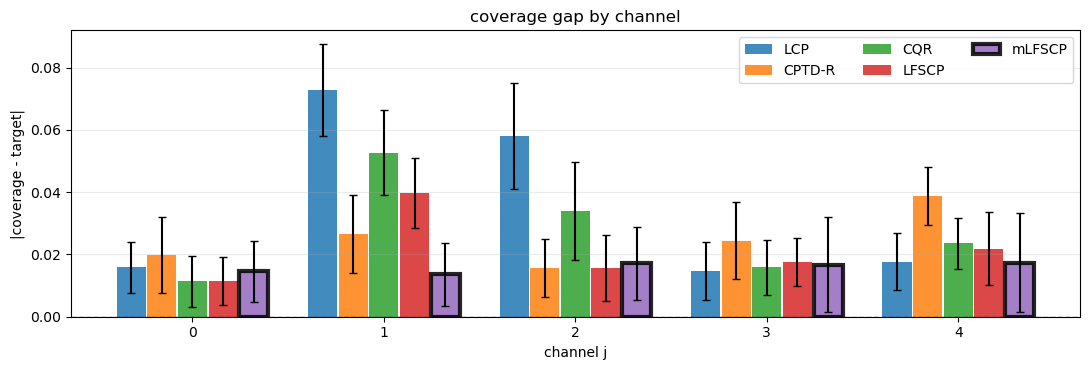

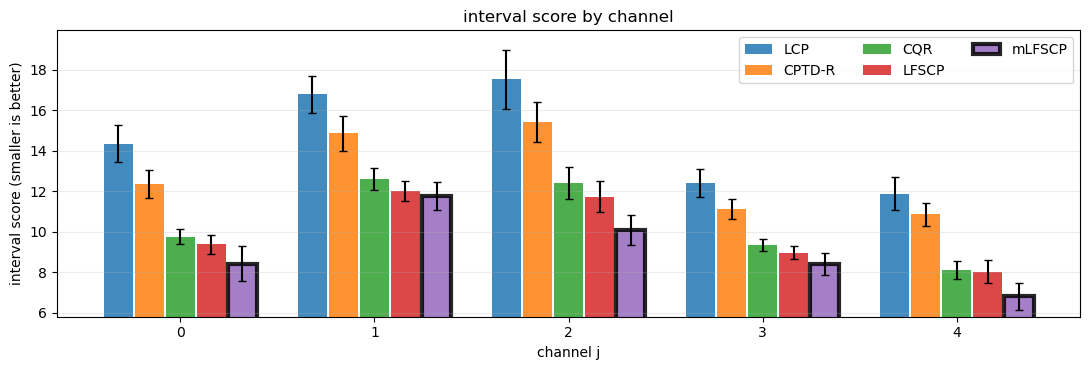

In [28]:
from twfv.plot import plot_methods_by_time_and_channel_coverage_and_interval_score_aggregated
(fig_time_cov, fig_time_sc, fig_ch_cov, fig_ch_sc), summary = plot_methods_by_time_and_channel_coverage_and_interval_score_aggregated(
        artifacts,
        method_labels={"tmfv": "LFSCP", "lcp": "LCP", "cptdr": "CPTD-R","cqr": "CQR","decomp": "mLFSCP"},
        method_order=["lcp", "cptdr", "cqr", "tmfv", "decomp"],
        n_time_bins=10,
        show_gap=True,   # True -> plot |coverage-target|
        # save_plots=True,
        # save_basename="vm1_0303",
        x_jitter_frac=0.8,
        bold_method="decomp",
    )

In [ ]:
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_cptdr",
    report_key_b="report_tmfv",
    covered_key_a="covered_cptdr",
    covered_key_b="covered_tmfv",
    label_a="CPTDR",
    label_b="TWFV",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

In [50]:
def _rebin_piecewise_constant_from_report(report_X, edges_new, *, field="coverage", eps=1e-12):
    """
    Rebin a per-run quantile-binned report (piecewise constant per old bin)
    onto fixed edges_new by overlap weighting.

    Uses row["n"] as bin mass; assumes uniform distribution within each old bin.

    report_X schema (from twfv.metrics.binned_interval_stats_by_quantiles):
      { "edges": (B+1,), "rows": [ {left,right,n,coverage,avg_length,...}, ... ] }
    """
    edges_old = np.asarray(report_X["edges"], dtype=float)
    rows = report_X["rows"]
    B_old = len(rows)
    B_new = len(edges_new) - 1
    out = np.full(B_new, np.nan, dtype=float)

    # Pre-pull old bin stats
    left_old = np.array([rows[b]["left"] for b in range(B_old)], dtype=float)
    right_old = np.array([rows[b]["right"] for b in range(B_old)], dtype=float)
    n_old = np.array([rows[b]["n"] for b in range(B_old)], dtype=float)
    val_old = np.array([rows[b].get(field, np.nan) for b in range(B_old)], dtype=float)

    width_old = np.maximum(right_old - left_old, 0.0)

    for k in range(B_new):
        l_new = float(edges_new[k])
        r_new = float(edges_new[k + 1])
        if r_new <= l_new:
            continue

        num = 0.0
        den = 0.0
        for b in range(B_old):
            if n_old[b] <= 0 or not np.isfinite(val_old[b]) or width_old[b] <= eps:
                continue

            overlap = max(0.0, min(r_new, right_old[b]) - max(l_new, left_old[b]))
            if overlap <= 0.0:
                continue

            # expected mass from old bin that falls into the overlap
            w = n_old[b] * (overlap / width_old[b])
            num += w * val_old[b]
            den += w

        if den > 0.0:
            out[k] = num / den

    return out


def aggregate_abs_gap_from_reports_fixed_edges(
    artifacts,
    *,
    report_key_a="report_tmfv",
    report_key_b="report_avg",
    key="X",
    alpha_target=0.1,
    edges_fixed=None,     # if None, build from global min/max of all report edges
    n_bins=10,
):
    target = 1.0 - float(alpha_target)

    # Build fixed edges if not provided
    if edges_fixed is None:
        mins = []
        maxs = []
        for art in artifacts:
            e_a = np.asarray(art[report_key_a][key]["edges"], dtype=float)
            e_b = np.asarray(art[report_key_b][key]["edges"], dtype=float)
            mins.append(np.nanmin(e_a)); mins.append(np.nanmin(e_b))
            maxs.append(np.nanmax(e_a)); maxs.append(np.nanmax(e_b))
        lo = float(np.nanmin(mins))
        hi = float(np.nanmax(maxs))
        edges_fixed = np.linspace(lo, hi, int(n_bins) + 1)

    edges_fixed = np.asarray(edges_fixed, dtype=float)
    centers = 0.5 * (edges_fixed[:-1] + edges_fixed[1:])

    gaps_a_runs = []
    gaps_b_runs = []

    for art in artifacts:
        rep_a_X = art[report_key_a][key]
        rep_b_X = art[report_key_b][key]

        cov_a = _rebin_piecewise_constant_from_report(rep_a_X, edges_fixed, field="coverage")
        cov_b = _rebin_piecewise_constant_from_report(rep_b_X, edges_fixed, field="coverage")

        gaps_a_runs.append(np.abs(cov_a - target))
        gaps_b_runs.append(np.abs(cov_b - target))

    G_a = np.stack(gaps_a_runs, axis=0)  # (n_runs, n_bins_fixed)
    G_b = np.stack(gaps_b_runs, axis=0)

    G_a_mean = np.nanmean(G_a, axis=0)
    G_a_sd = np.nanstd(G_a, axis=0)
    G_b_mean = np.nanmean(G_b, axis=0)
    G_b_sd = np.nanstd(G_b, axis=0)

    return centers, G_a_mean, G_a_sd, G_b_mean, G_b_sd, edges_fixed


def plot_abs_gap_from_reports_fixed_edges(
    artifacts,
    *,
    report_key_a="report_tmfv",
    report_key_b="report_avg",
    label_a="A",
    label_b="B",
    key="X",
    alpha_target=0.1,
    edges_fixed=None,
    n_bins=10,
    title=None,
):
    centers, G_a_mean, G_a_sd, G_b_mean, G_b_sd, edges_fixed = aggregate_abs_gap_from_reports_fixed_edges(
        artifacts,
        report_key_a=report_key_a,
        report_key_b=report_key_b,
        key=key,
        alpha_target=alpha_target,
        edges_fixed=edges_fixed,
        n_bins=n_bins,
    )

    fig, ax = plt.subplots(figsize=(10.5, 3.6))
    ax.plot(centers, G_a_mean, marker="o", label=f"{label_a}: mean |cov-target|")
    ax.fill_between(centers, G_a_mean - G_a_sd, G_a_mean + G_a_sd, alpha=0.20)

    ax.plot(centers, G_b_mean, marker="o", label=f"{label_b}: mean |cov-target|")
    ax.fill_between(centers, G_b_mean - G_b_sd, G_b_mean + G_b_sd, alpha=0.20)

    ax.axhline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel(f"{key} (fixed-bin centers)")
    ax.set_ylabel("|coverage - target|")
    ax.set_title(title or f"{key}: abs conditional coverage gap (target={1-alpha_target:.2f})")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig, ax, edges_fixed

In [ ]:
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_cptdr",
    report_key_b="report_oracle",
    covered_key_a="covered_cptdr",
    covered_key_b="covered_oracle",
    label_a="CPTDR",
    label_b="Oracle",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    save_plots=False,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
    oracle_shorter_coef=.7,
)

In [ ]:
plot_compare_conditional_reports_aggregated(
    artifacts,
    report_key_a="report_oracle",
    report_key_b="report_tmfv",
    covered_key_a="covered_oracle",
    covered_key_b="covered_tmfv",
    label_a="oracle",
    label_b="TWFV",
    key="X",
    n_time_bins=10,
    alpha_target=0.1,
    save_plots=False,
    heatmap_style = "contourf",
    heatmap_levels=20,
    heatmap_upsample=3,
)

In [172]:
from twfv.plot import build_methods_macro_table_from_artifacts
tab = build_methods_macro_table_from_artifacts(
    artifacts,
    n_time_bins=10,
    min_group_size=20,
    coverage_tol=0.03,
    method_labels={"tmfv": "LFSCP", "lcp": "LCP", "cptdr": "CPTD-R","cqr": "CQR","decomp": "Decomp"},
    method_order=["decomp", "tmfv", "lcp", "cptdr", "cqr"],
    digits_cov=1
)

print(tab["latex"])  

\begin{table*}[t]
\centering
\caption{Coverage and interval score across conditioning partitions. Values are macro-averaged over groups within each partition and reported as mean$\pm$sd over runs. In Panel A, $\Delta$ denotes coverage minus target $(1-\alpha)$; bold/underline = best/second-best (smallest $|\Delta|$) among methods that satisfy coverage (no dagger). In Panel B, lower is better; bold/underline = best/second-best (lowest) interval score among methods that satisfy coverage.}
\label{tab:main_comparison}
\small
\setlength{\tabcolsep}{6pt}
\begin{minipage}{\textwidth}
\subcaption*{\textbf{Panel A: Coverage}}
\begin{tabular}{lccccc}
\toprule
Condition & Decomp & LFSCP & LCP & CPTD-R & CQR \\
\midrule
Overall & \textbf{89.4 (-0.6) ± 0.7} & 88.3 (-1.7) ± 0.7 & 87.4 (-2.6) ± 0.8 & \underline{91.2 (+1.2) ± 0.6} & 87.5 (-2.5) ± 0.4 \\
Time bins & \textbf{89.4 (-0.6) ± 0.6} & 88.3 (-1.7) ± 0.6 & 87.4 (-2.6) ± 0.8 & \underline{91.1 (+1.1) ± 0.6} & 87.5 (-2.5) ± 0.4 \\
Channel & \textb

In [ ]:
from twfv.plot import build_methods_macro_table_from_artifacts
tab = build_methods_macro_table_from_artifacts(
    artifacts,
    n_time_bins=10,
    min_group_size=20,
    coverage_tol=0.03,
    method_labels={"tmfv": "LFSCP", "lcp": "LCP", "cptdr": "CPTD-R","cqr": "CQR","decomp": "mLFSCP"},
    method_order=["decomp", "tmfv", "lcp", "cptdr", "cqr"],
    digits_cov=1,
    panel_a_mode="coverage_gap"
)

print(tab["latex"]) 

\begin{table*}[t]
\centering
\caption{Coverage gap and interval score across conditioning partitions. Values are macro-averaged over groups within each partition and reported as mean$\pm$sd over runs. In Panel A, coverage gap $=|$empirical coverage $-$ target$|$ (in \%); bold/underline = best/second-best (smallest gap) among methods that satisfy coverage (no dagger). In Panel B, lower is better; bold/underline = best/second-best (lowest) interval score among methods that satisfy coverage.}
\label{tab:main_comparison}
\small
\setlength{\tabcolsep}{6pt}
\begin{minipage}{\textwidth}
\subcaption*{\textbf{Panel A: Coverage gap}}
\begin{tabular}{lccccc}
\toprule
Condition & mLFSCP & LFSCP & LCP & CPTD-R & CQR \\
\midrule
Overall & \underline{1.1 ± 0.8} & 1.9 ± 0.9 & 2.9 ± 0.9 & \textbf{1.1 ± 0.6} & 2.7 ± 0.8 \\
Time bins & \underline{2.1 ± 0.5} & 2.2 ± 0.6 & 3.1 ± 0.6 & \textbf{2.0 ± 0.5} & 2.9 ± 0.6 \\
Channel & \textbf{1.6 ± 0.8} & \underline{2.1 ± 0.7} & 3.6 ± 0.7 & 2.5 ± 0.4 & 2.8 ± 0.7 

In [148]:
from twfv.plot import build_methods_macro_table_from_artifacts
tab = build_methods_macro_table_from_artifacts(
    artifacts,
    n_time_bins=10,
    min_group_size=20,
    coverage_tol=0.03,
    method_labels={"tmfv": "LFSCP", "lcp": "LCP", "cptdr": "CPTD-R","cqr": "CQR","decomp": "Decomp"},
    method_order=["decomp", "tmfv", "lcp", "cptdr", "cqr"],
    digits_cov=1
)

print(tab["latex"])  

\begin{table*}[t]
\centering
\caption{Coverage and interval score across conditioning partitions. Values are macro-averaged over groups within each partition and reported as mean$\pm$sd over runs. In Panel A, $\Delta$ denotes coverage minus target $(1-\alpha)$; bold/underline = best/second-best (smallest $|\Delta|$) among methods that satisfy coverage (no dagger). In Panel B, lower is better; bold/underline = best/second-best (lowest) interval score among methods that satisfy coverage.}
\label{tab:main_comparison}
\small
\setlength{\tabcolsep}{6pt}
\begin{minipage}{\textwidth}
\subcaption*{\textbf{Panel A: Coverage}}
\begin{tabular}{lccccc}
\toprule
Condition & Decomp & LFSCP & LCP & CPTD-R & CQR \\
\midrule
Overall & \textbf{88.9 (-1.1) ± 0.7} & 88.3 (-1.7) ± 0.7 & 87.4 (-2.6) ± 0.8 & \underline{91.2 (+1.2) ± 0.6} & 87.5 (-2.5) ± 0.4 \\
Time bins & \textbf{88.9 (-1.1) ± 0.7} & 88.3 (-1.7) ± 0.6 & 87.3 (-2.7) ± 0.8 & \underline{91.1 (+1.1) ± 0.6} & 87.5 (-2.5) ± 0.4 \\
Channel & \textb

In [149]:
tab = build_methods_macro_table_from_artifacts(
    artifacts,
    n_time_bins=10,
    min_group_size=20,
    coverage_tol=0.03,
    method_labels={"tmfv": "LFSCP", "lcp": "LCP", "cptdr": "CPTD-R","cqr": "CQR","decomp": "Decomp"},
    method_order=["decomp", "tmfv", "lcp", "cptdr", "cqr"],
    digits_cov=1,
    panel_a_mode="coverage_gap"
)

print(tab["latex"]) 

\begin{table*}[t]
\centering
\caption{Coverage gap and interval score across conditioning partitions. Values are macro-averaged over groups within each partition and reported as mean$\pm$sd over runs. In Panel A, coverage gap $=|$empirical coverage $-$ target$|$ (in \%); bold/underline = best/second-best (smallest gap) among methods that satisfy coverage (no dagger). In Panel B, lower is better; bold/underline = best/second-best (lowest) interval score among methods that satisfy coverage.}
\label{tab:main_comparison}
\small
\setlength{\tabcolsep}{6pt}
\begin{minipage}{\textwidth}
\subcaption*{\textbf{Panel A: Coverage gap}}
\begin{tabular}{lccccc}
\toprule
Condition & Decomp & LFSCP & LCP & CPTD-R & CQR \\
\midrule
Overall & \textbf{1.1 ± 0.7} & 1.7 ± 0.7 & 2.6 ± 0.8 & \underline{1.2 ± 0.6} & 2.5 ± 0.4 \\
Time bins & \textbf{2.0 ± 0.4} & 2.1 ± 0.5 & 2.9 ± 0.7 & \underline{2.0 ± 0.5} & 2.6 ± 0.4 \\
Channel & \textbf{1.3 ± 0.6} & \underline{1.9 ± 0.5} & 3.4 ± 0.8 & 2.5 ± 0.5 & 2.6 ± 0.4 

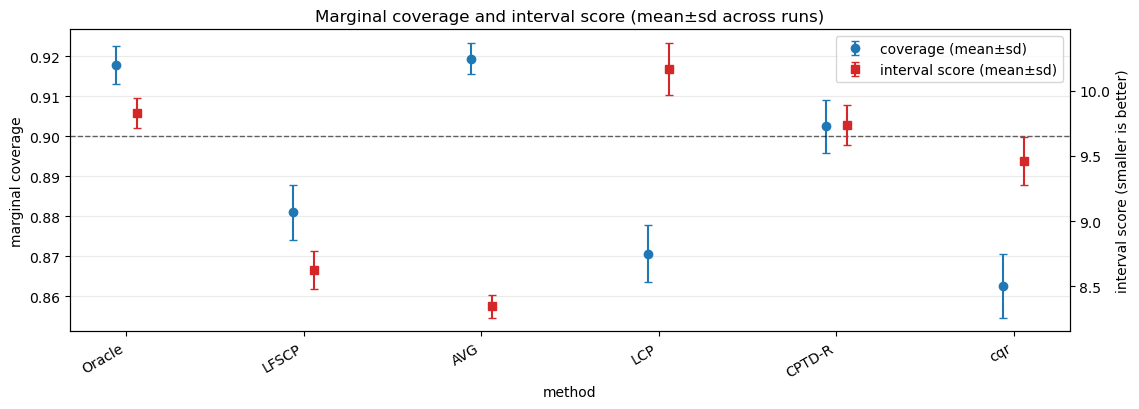

In [ ]:
fig, (ax_cov, ax_sc), summary = plot_methods_marginal_coverage_and_interval_score(
    artifacts,
    method_labels={"tmfv": "LFSCP", "avg": "AVG", "oracle": "Oracle", "lcp": "LCP", "cptdr": "CPTD-R"},
    method_order=["oracle", "tmfv", "avg", "lcp", "cptdr"],
    save_plots=False,
    save_basename="all_methods",
)

In [ ]:
from twfv.diagnostics import summarize_em_diagnostics, quickplot_em_diagnostics

diag = summarize_em_diagnostics(em_result[7])
quickplot_em_diagnostics(diag)

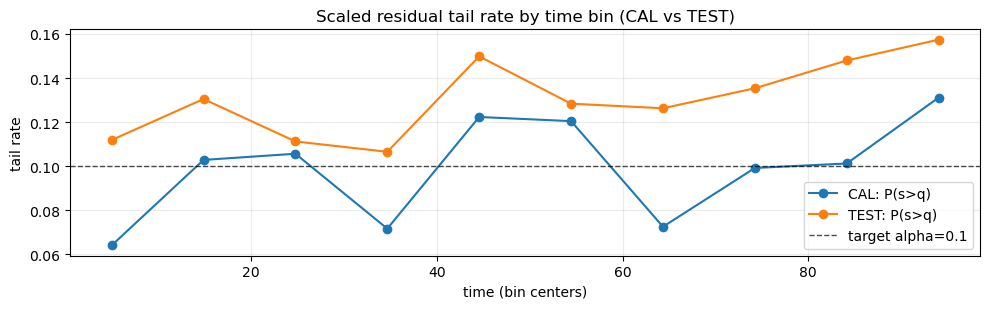

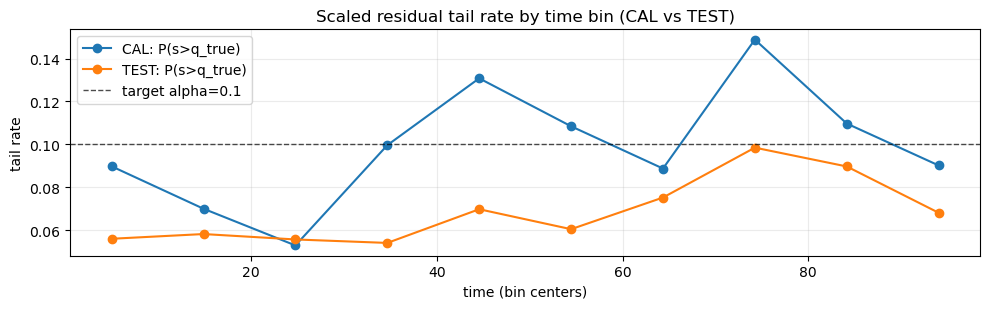

In [37]:
from twfv import cal_test_scaled_residual_diagnostics

# tmfv_result = (lower, upper, q)
q = float(tmfv_result[2])

# Build "flat" y arrays aligned with k = i*(J*T) + j*T + t
Y_flat_true = np.full(I * J * T, np.nan, dtype=float)
Y_flat_fit  = np.full(I * J * T, 0.0, dtype=float)  # you use yhat=0

Y_flat_true[cal_idx] = Y_cal_true
Y_flat_true[test_idx] = Y_test_true
Y_flat_fit[cal_idx] = Y_cal_fit
Y_flat_fit[test_idx] = Y_test_fit

diag_ct = cal_test_scaled_residual_diagnostics(
    cal_idx=cal_idx,
    test_idx=test_idx,
    Y_flat_true=Y_flat_true,
    Y_flat_fit=Y_flat_fit,
    sigma_flat=sigma_flat,
    I=I, J=J, T=T,
    q=q,
    n_time_bins=10,
)

cent = diag_ct.cal["centers"]
plt.figure(figsize=(10, 3.2))
plt.plot(cent, diag_ct.cal["tail"], marker="o", label="CAL: P(s>q)")
plt.plot(cent, diag_ct.test["tail"], marker="o", label="TEST: P(s>q)")
plt.axhline(0.1, color="k", ls="--", lw=1, alpha=0.7, label="target alpha=0.1")
plt.xlabel("time (bin centers)")
plt.ylabel("tail rate")
plt.title("Scaled residual tail rate by time bin (CAL vs TEST)")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()
sigma_true_flat = np.transpose(np.sqrt(local_var_Y), (0, 2, 1)).reshape(-1)  # (I*J*T,)
q_true = oracle_result[2]
diag_ct_true = cal_test_scaled_residual_diagnostics(
    cal_idx=cal_idx,
    test_idx=test_idx,
    Y_flat_true=Y_flat_true,
    Y_flat_fit=Y_flat_fit,
    sigma_flat=sigma_true_flat,
    I=I, J=J, T=T,
    q=q_true,
    n_time_bins=10,
)
cent = diag_ct.cal["centers"]
plt.figure(figsize=(10, 3.2))
plt.plot(cent, diag_ct_true.cal["tail"], marker="o", label="CAL: P(s>q_true)")
plt.plot(cent, diag_ct_true.test["tail"], marker="o", label="TEST: P(s>q_true)")
plt.axhline(0.1, color="k", ls="--", lw=1, alpha=0.7, label="target alpha=0.1")
plt.xlabel("time (bin centers)")
plt.ylabel("tail rate")
plt.title("Scaled residual tail rate by time bin (CAL vs TEST)")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [ ]:
figs = make_diagnosis_plots(
    t=t_test,
    y_true=Y_test_true,
    y_hat=Y_test_fit,      # or None -> defaults to 0
    sigma=sigma_test,
    lower=lower_tmfv,
    upper=upper_tmfv,
    q=tmfv_result[2],
    alpha=0.1,
    early_t_max=30,
    n_time_bins=10,
    title_prefix="TWFV",
    # y_max=8.5
)

In [ ]:
from twfv import plot_compare_conditional_reports
subj_test = np.zeros(test_idx.size, dtype=int)
chan_test = np.zeros(test_idx.size, dtype=int)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    subj_test[n] = i
    chan_test[n] = j

plot_compare_conditional_reports(
    report_tmfv,
    report_scp,
    label_a="TWFV",
    label_b="SCP",
    coverage_mode = "gap",
    report_oracle = report_oracle,
    keys=("X"),   # whichever you computed
    alpha_target=0.1,              # draws target coverage line at 0.9
    title="Conditional coverage/length by quantile bins",
    channel_ids=chan_test,
    subject_ids=subj_test,
    time_ids=t_test,
    covered_a=covered_tmfv,   # bool (n_test,)
    covered_b=covered_scp,
    covered_oracle = covered_oracle,
    heatmap_mode="timebin_subject",   # or "timebin_channel" / "subject_channel"
    n_time_bins=10,
    save_plots=False,
    save_basename="twfv_vs_scp",
    heatmap_style="contourf",
    heatmap_levels= 20,
    heatmap_upsample = 3,
)

In [ ]:
# Assumes:
# - Y has shape (I, T, J)
# - flatten convention: k = i*(J*T) + j*T + t, with i in [0..I-1], j in [0..J-1], t in [0..T-1]
# - train_idx, cal_idx, test_idx already built like in your @run.ipynb (1-20)
from sklearn.linear_model import QuantileRegressor
from scripts.cqr import ConformalQuantileRegressor
# 1) Build X for ALL (i,j,t) in the SAME order as k = i*(J*T)+j*T+t
ii = np.repeat(np.arange(I ), J * T)                          # (I*J*T,)
jj = np.tile(np.repeat(np.arange(J), T), I)                  # (I*J*T,)
tt = np.tile(np.arange(T), I * J)                            # (I*J*T,)
X_all = np.stack([ii, jj, tt], axis=1).astype(float)                # (I*J*T, 3)

# 2) Flatten Y to match the same k-order: (i,j,t) major order
y_all = np.transpose(Y, (0, 2, 1)).reshape(-1).astype(float)        # (I*J*T,)

# 3) Slice by your split indices
train_idx = np.asarray(train_idx, dtype=int)
cal_idx   = np.asarray(cal_idx, dtype=int)
test_idx  = np.asarray(test_idx, dtype=int)

X_train, y_train   = X_all[train_idx], y_all[train_idx]
X_calib, y_calib   = X_all[cal_idx],   y_all[cal_idx]
X_test,  y_test    = X_all[test_idx],  y_all[test_idx]


# cqr = ConformalQuantileRegressor(alpha=0.1, n_estimators=100, random_state=0)

cqr = ConformalQuantileRegressor(alpha=0.1, quantile_regressor=QuantileRegressor,reg_alpha=0.0)
cqr.fit(X_train, y_train, X_calib, y_calib)

# Predict intervals on test set
lower_bounds, upper_bounds = cqr.predict_interval(X_test)
covered_cqr = (y_test >= lower_bounds) & (y_test <= upper_bounds)
# Check empirical coverage on test data
coverage = np.mean((y_test >= lower_bounds) & (y_test <= upper_bounds))
print(f"Empirical coverage on test set: {coverage*100:.1f}%")
# Example: output might be "Empirical coverage on test set: 92.0%" (close to 90% target)

report_cqr = conditional_interval_report(
    y_true=y_test,
    lower=lower_bounds,
    upper=upper_bounds,
    x=t_test,
    y_hat=Y_test_fit,  # optional
    n_bins=5,
)

Empirical coverage on test set: 81.2%


In [ ]:
from twfv import plot_compare_conditional_reports
subj_test = np.zeros(test_idx.size, dtype=int)
chan_test = np.zeros(test_idx.size, dtype=int)
for n, k in enumerate(test_idx.tolist()):
    i, j, t = unflatten(int(k), I, J, T)
    subj_test[n] = i
    chan_test[n] = j

plot_compare_conditional_reports(
    report_tmfv,
    report_cqr,
    label_a="TWFV",
    label_b="CQR",
    coverage_mode = "gap",
    report_oracle = report_oracle,
    keys=("X"),   # whichever you computed
    alpha_target=0.1,              # draws target coverage line at 0.9
    title="Conditional coverage/length by quantile bins",
    channel_ids=chan_test,
    subject_ids=subj_test,
    time_ids=t_test,
    covered_a=covered_tmfv,   # bool (n_test,)
    covered_b=covered_cqr,
    covered_oracle = covered_oracle,
    heatmap_mode="timebin_subject",   # or "timebin_channel" / "subject_channel"
    n_time_bins=10,
    save_plots=False,
    save_basename="twfv_vs_cqr",
    heatmap_style="contourf",
    heatmap_levels= 20,
    heatmap_upsample = 3,
)

In [155]:
import torch
from twfv.variance import build_a2_from_C_and_warp

def local_var_from_fit(L, a2, psi, s, C, u_tilde, knots, degree):
    with torch.no_grad():
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))             # sum_k L^2 * a2
        var = base + (s**2)[:, None, None] * psi[None, None, :]     # add noise diag
    return var  # shape (I, T, J)

In [156]:
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4], em_result[5], knots, degree).cpu().numpy()

In [100]:
from twfv.cp import CPTDRSplitConformalCP
cp = CPTDRSplitConformalCP(shape_ref=Y, J=J, alpha=float(alpha))
cp.calibrate_from_fit(
    X_cal_idx=np.asarray(cal_idx, dtype=int).ravel(),
    Y_cal_true=Y_cal_true,
    Y_cal_fit=Y_cal_fit,
    X_hist_idx=np.asarray(train_idx, dtype=int).ravel(),
    Y_hist_true=Y_flat[np.asarray(train_idx, dtype=int).ravel()],
    Y_hist_fit=np.zeros_like(Y_flat[np.asarray(train_idx, dtype=int).ravel()]),
)
intervals_cptdr = cp.predict_interval_from_fit(
    X_test_idx=test_idx,
    Y_test_fit=Y_test_fit,
    alpha=float(alpha),
)
lower_cptdr = intervals_cptdr[:, 0]
upper_cptdr = intervals_cptdr[:, 1]
covered_cptdr = (Y_test_true >= lower_cptdr) & (Y_test_true <= upper_cptdr)
report_cptdr = conditional_interval_report(
    y_true=Y_test_true,
    lower=lower_cptdr,
    upper=upper_cptdr,
    x=t_test,
    y_hat=Y_test_fit,
    n_bins=int(n_bins),
)

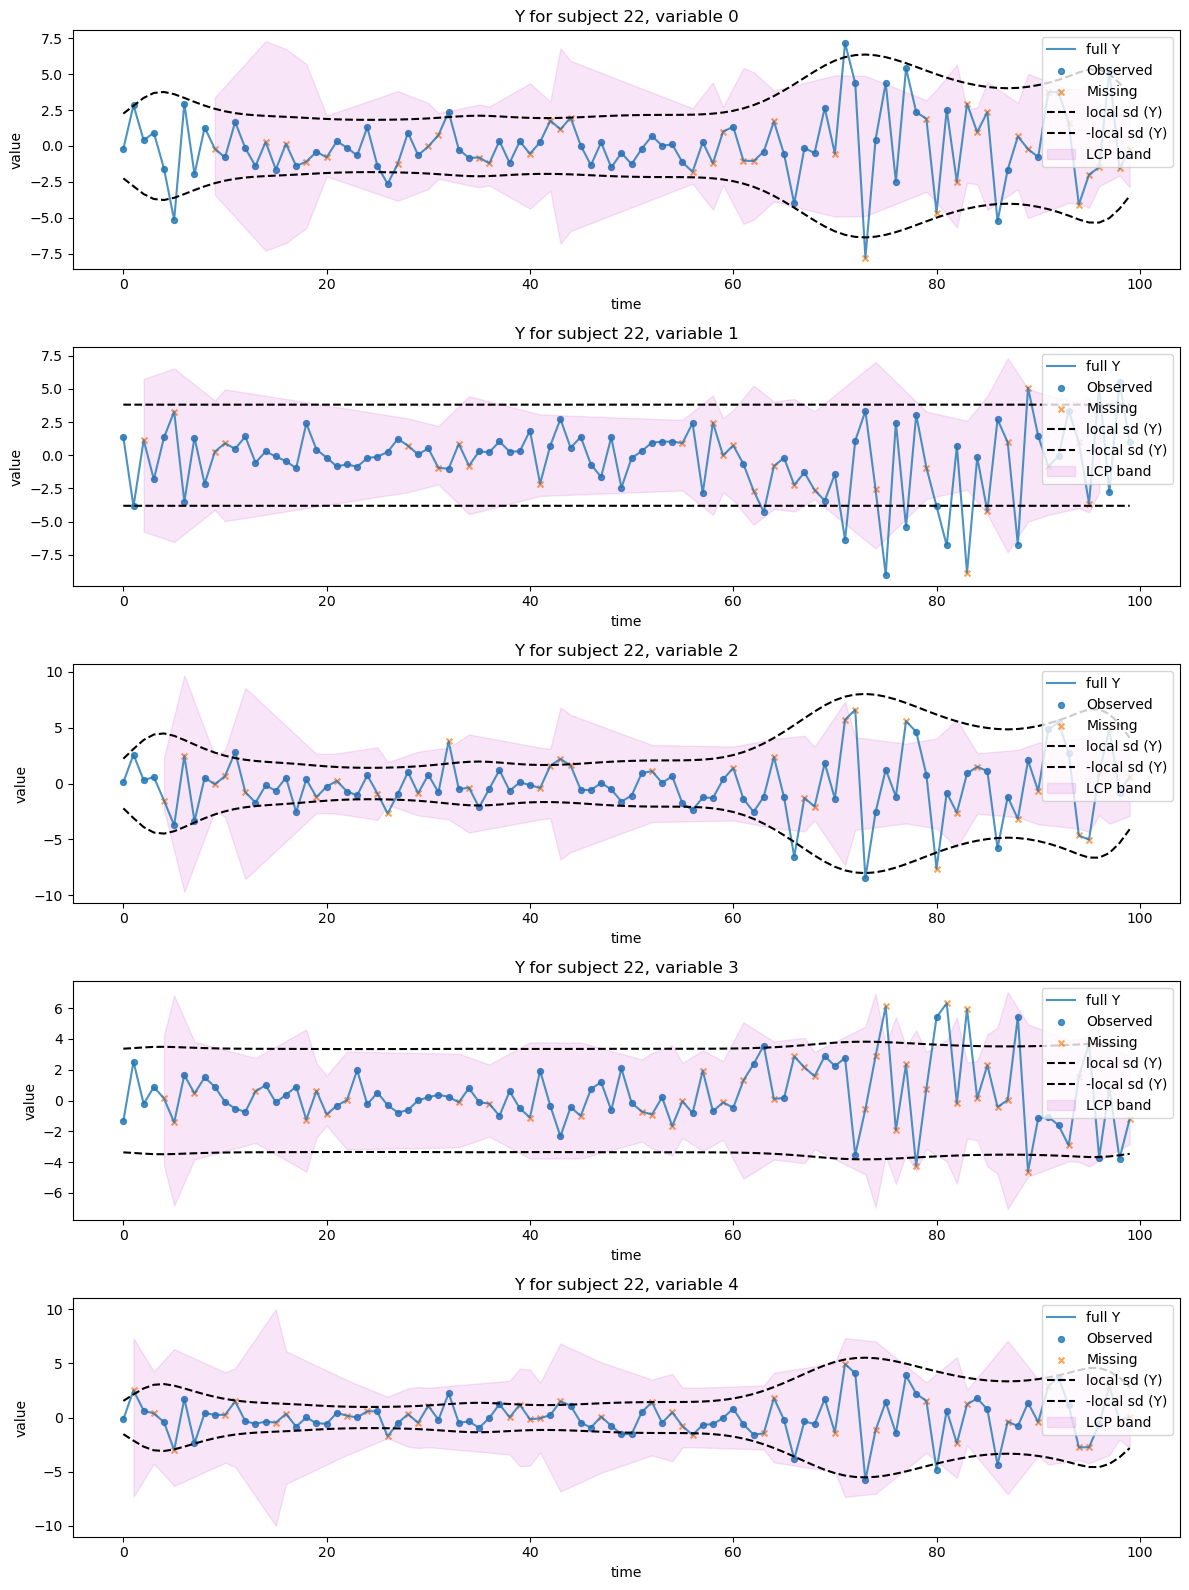

In [16]:
# Plot Y for subject 2, channels 0-4, showing observed and missing with different colors
subject_id = 22
plt.figure(figsize=(12, 16))
for j in range(J):
    plt.subplot(5, 1, j + 1)
    y_vals = Y[subject_id, :, j]  # shape (T,)
    m_mask = M[subject_id, :, j]  # shape (T,)
    t_vals = np.arange(Y.shape[1])

    # Plot full Y curve
    plt.plot(t_vals, y_vals, color='C0', label='full Y', alpha=0.8)
    # Observed points
    plt.scatter(t_vals[m_mask], y_vals[m_mask], color='C0', label='Observed', alpha=0.8, s=18)
    # Missing points
    plt.scatter(t_vals[~m_mask], y_vals[~m_mask], color='C1', label='Missing', alpha=0.7, s=18, marker='x')

    var = local_var_fitted[subject_id, :, j]  # shape (T,)
    plt.plot(t_vals, np.sqrt(var)*tmfv_result[2], 'k--', label='local sd (Y)')
    plt.plot(t_vals, -np.sqrt(var)*tmfv_result[2], 'k--', label='-local sd (Y)')

    # Add LCP conformal prediction interval, if available
    # Yhat_flat is (I*J*T,); lower_lcp and upper_lcp are (test_idx.size,)
    # We'll extract the relevant flat indices corresponding to this subject and channel
    yhat_lcp = Yhat_flat.reshape((I, J, T))
    # Collect (t, lower, upper) for this (subject_id, j) across all t where in test_idx
    t_plot = []
    lower_plot = []
    upper_plot = []
    for t in range(T):
        flat_idx = flatten(subject_id, j, t, I, J, T)
        if flat_idx in test_idx:
            pos = np.where(test_idx == flat_idx)[0][0]
            t_plot.append(t)
            lower_plot.append(lower_cptdr[pos])
            upper_plot.append(upper_cptdr[pos])
    # Now plot all at once, with labels only on first call to avoid repetitive legend
    if len(t_plot) > 0:
        plt.fill_between(t_plot, lower_plot, upper_plot, color='m', alpha=0.1, label='LCP band')

    plt.title(f"Y for subject {subject_id}, variable {j}")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

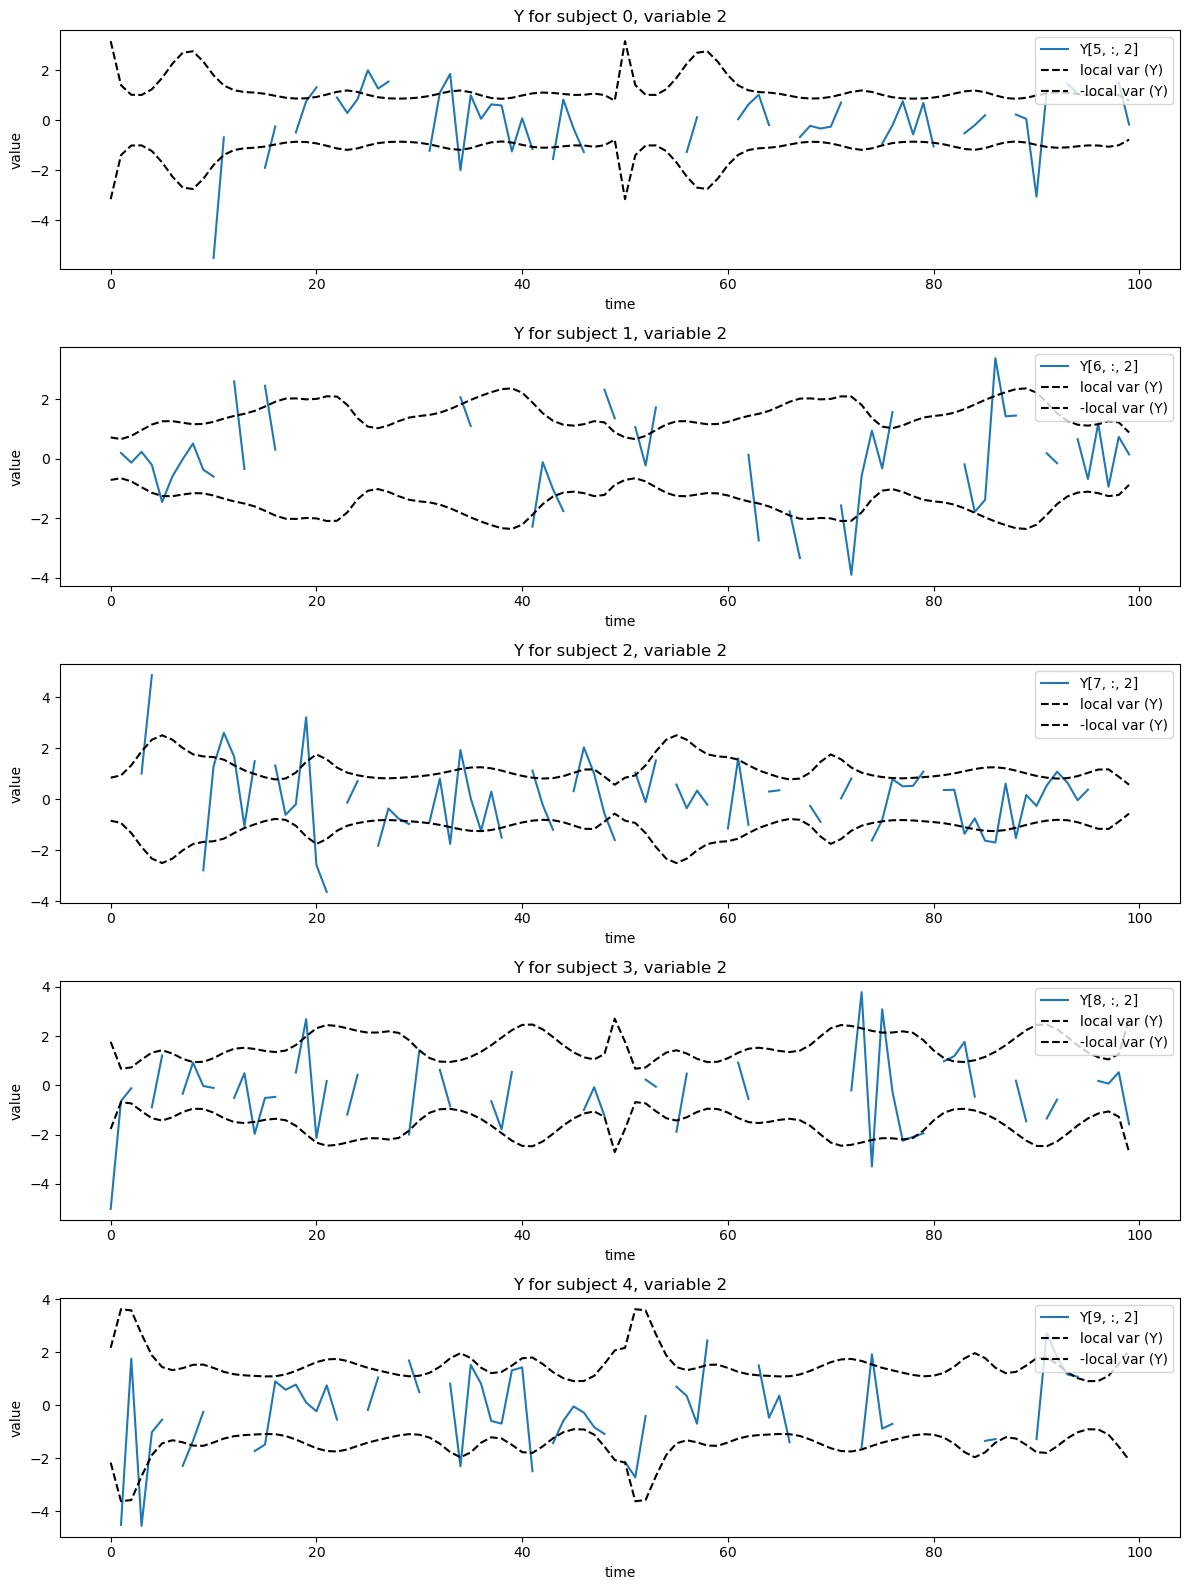

In [124]:

import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
incre=5
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(YM[i+incre, :, 2], label=f"Y[{i+incre}, :, 2]")
    var = local_var_fitted[i+incre, :, 2]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for subject {i}, variable 2")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()
